# **Import**

In [1]:
# Install required packages
%pip install -q datasets
%pip install -q transformers
%pip install -q sentence-transformers
%pip install -q nltk
%pip install -q google-generativeai
%pip install -q rouge-score bert-score
%pip install seaborn


import os
import sys
from datasets import load_dataset
import json
from transformers import pipeline, set_seed
import numpy as np
import random
import torch
from huggingface_hub import login
import getpass
import gc

import string
import re
import nltk
from nltk.tokenize import word_tokenize
from nltk.translate import meteor_score
from rouge_score import rouge_scorer
from bert_score import BERTScorer

import pandas as pd
from IPython.display import display

import google.generativeai as genai
import time

from sklearn.metrics import cohen_kappa_score
import matplotlib.pyplot as plt
import seaborn as sns

from sentence_transformers import CrossEncoder
import requests

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.


...


[notice] A new release of pip is available: 26.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip

[notice] A new release of pip is available: 26.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.


W0605 14:21:25.661000 22436 site-packages\torch\distributed\elastic\multiprocessing\redirects.py:29] NOTE: Redirects are currently not supported in Windows or MacOs.
C:\Users\djmat\AppData\Local\Temp\ipykernel_22436\1076729895.py:34: FutureWarning: 

All support for the `google.generativeai` package has ended. It will no longer be receiving 
updates or bug fixes. Please switch to the `google.genai` package as soon as possible.
See README for more details:

https://github.com/google-gemini/deprecated-generative-ai-python/blob/main/README.md

  import google.generativeai as genai


# **Seed to ensure reproducibility**

In [2]:
def set_seeds(seed=42):

    random.seed(seed)
    
    np.random.seed(seed)
    os.environ['PYTHONHASHSEED'] = str(seed)

    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)

        torch.backends.cudnn.deterministic = True
        torch.backends.cudnn.benchmark = False

    # Seed on transformers library
    set_seed(seed)


set_seeds(seed=42)

# **Hugging Face Login**

In [3]:
kaggle = False

# Insert the hugging face token
if 'KAGGLE_KERNEL_RUN_TYPE' in os.environ:
    kaggle = True
    try:
        from kaggle_secrets import UserSecretsClient
        user_secrets = UserSecretsClient()
        hf_token = user_secrets.get_secret("HF_TOKEN")

        login(token=hf_token)
        print("✅ You have been automatically logged in to Hugging Face!")

    except Exception as e:
        print("❌ Error Kaggle Secrets: Token not found.")
else:
    print("Please enter your Hugging Face Access Token: (You must have access to Llama 3.2):")
    hf_token = getpass.getpass()
    login(token=hf_token)

Please enter your Hugging Face Access Token: (You must have access to Llama 3.2):


# **Environment Setup**

In [4]:
colab = False

# Automatic Environment Detection

# We re using google colab
if 'google.colab' in sys.modules:
    print("🌐 Environment detected: Google Colab")
    colab = True

    # Automatically mount Google Drive
    from google.colab import drive
    drive.mount('/content/drive')

    BASE_DIR = '/content/drive/MyDrive/MNLP_2026_HW2_2278125_2283937/'

# We are using Kaggle
elif kaggle:
    print("🔵 Environment detected: Kaggle")

    BASE_DIR = '/kaggle/working/'

# We are in local machine
else:
    print("💻 Environment detected: Local Machine")
    BASE_DIR = 'C:/Users/djmat/Desktop/Magistrale - Engineering in CS and AI - Sapienza/Multilingual_Natural_Language_Processing/MNLP_Project_2026'

# Defining paths for subdirectories
if kaggle:
    JSON_DIR = '/kaggle/input/datasets/nicolromanelli/json-kaggle'
else:
    JSON_DIR = os.path.join(BASE_DIR, 'JSON')

PLOTS_DIR = os.path.join(BASE_DIR, 'plots')
OUTPUTS_DIR = os.path.join(BASE_DIR, 'outputs')
NO_REQUESTED_OUTPUTS_DIR = os.path.join(BASE_DIR, 'no_requested_outputs')

# Creating directories if they don't exist
os.makedirs(JSON_DIR, exist_ok=True)
os.makedirs(PLOTS_DIR, exist_ok=True)
os.makedirs(OUTPUTS_DIR, exist_ok=True)
os.makedirs(NO_REQUESTED_OUTPUTS_DIR, exist_ok=True)

print(f"📁 Base Directory set to: {BASE_DIR}")

# Set up hardware acceleration (GPU if available, else CPU)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"🚀 Device selected: {device}")

💻 Environment detected: Local Machine
📁 Base Directory set to: C:/Users/djmat/Desktop/Magistrale - Engineering in CS and AI - Sapienza/Multilingual_Natural_Language_Processing/MNLP_Project_2026
🚀 Device selected: cuda


# **GPU Usage Debugging Function**

In [ ]:
def gpu_status(label=""):
    allocated = torch.cuda.memory_allocated(0) / 1024**3
    reserved  = torch.cuda.memory_reserved(0)  / 1024**3
    total     = torch.cuda.get_device_properties(0).total_memory / 1024**3
    free      = total - reserved
    print(f"[GPU {label}]")
    print(f"  Allocated:  {allocated:.2f} GB")
    print(f"  Reserved: {reserved:.2f} GB")
    print(f"  Free:    {free:.2f} GB")
    print(f"  Total:    {total:.2f} GB")

# **Dataset Loading and Exploration**

In [5]:
ds = load_dataset(
    "sapienzanlp-course-materials/hw-mnlp-2026"
)

# Sanity check
for split in ds.keys():
    print(f"Split: {split:6} | Features: {ds[split].column_names}")

# Unpack splits into dedicated variables for easier access
train = ds['train']
test = ds['test']
blind = ds['blind']

Split: test   | Features: ['wikipedia_title', 'wikidata_id', 'query', 'query_id', 'candidate_chunks', 'n_candidates', 'answer', 'answer_pos', 'short_answer']
Split: blind  | Features: ['wikipedia_title', 'wikidata_id', 'query', 'query_id', 'candidate_chunks', 'n_candidates', 'answer', 'answer_pos', 'short_answer']
Split: train  | Features: ['wikipedia_title', 'wikidata_id', 'query', 'query_id', 'candidate_chunks', 'n_candidates', 'answer', 'answer_pos', 'short_answer']


# **Rankings Loading**

In [6]:
# Rankings file name definition
rankings_test_filename = 'hit_k_1-test-distilbert-triplet-cosine_(reranking).jsonl'
rankings_blind_filename = 'hit_k_1-blind-distilbert-triplet-cosine_(reranking).jsonl'

# Complete path creation
rankings_test_path = os.path.join(JSON_DIR, rankings_test_filename)
rankings_blind_path = os.path.join(JSON_DIR, rankings_blind_filename)

retrieved_results_test = []
retrieved_results_blind = []

# Test set Rankings loading
try:
    with open(rankings_test_path, 'r', encoding='utf-8') as f:
        for line in f:
            retrieved_results_test.append(json.loads(line.strip()))

    print(f"✅ Test Set rankings loaded with success!")
    print(f"   📍 File: {rankings_test_path}")

except FileNotFoundError:
    print(f"❌ ERROR: TEST SET rankings does not found:\n{rankings_test_path}\n")


# Blind set Rankings loading
try:
    with open(rankings_blind_path, 'r', encoding='utf-8') as f:
        for line in f:
            retrieved_results_blind.append(json.loads(line.strip()))

    print(f"✅ Blind Set rankings loaded with success!")
    print(f"   📍 File: {rankings_blind_path}")

except FileNotFoundError:
    print(f"❌ ERROR: BLIND SET rankings does not found:\n{rankings_blind_path}")

# Unique Dictionary creation {'query_id1': [rankings], 'query_id2': [rankings], ...}
rankings_test = {}
for item in retrieved_results_test:
    rankings_test.update(item)

rankings_blind = {}
for item in retrieved_results_blind:
    rankings_blind.update(item)

✅ Test Set rankings loaded with success!
   📍 File: C:/Users/djmat/Desktop/Magistrale - Engineering in CS and AI - Sapienza/Multilingual_Natural_Language_Processing/MNLP_Project_2026\JSON\hit_k_1-test-distilbert-triplet-cosine_(reranking).jsonl
✅ Blind Set rankings loaded with success!
   📍 File: C:/Users/djmat/Desktop/Magistrale - Engineering in CS and AI - Sapienza/Multilingual_Natural_Language_Processing/MNLP_Project_2026\JSON\hit_k_1-blind-distilbert-triplet-cosine_(reranking).jsonl


# **JSON Functions**

In [7]:
# This function takes as input a dictionary and saves it in a JSONL file
def save_jsonl(dict, filename, dir):
    full_path = os.path.join(dir, filename)
    with open(full_path, 'w', encoding='utf-8') as f:
        for q_id in dict:
            json.dump(dict[q_id], f, ensure_ascii=False)
            f.write('\n')
    print(f"💾 File saved: {full_path}") 

# This function takes as input a JSON file and reload the exact same dictionary as before
def load_jsonl(filename, dir):

    full_path = os.path.join(dir, filename)
    loaded_answers = {}

    try:
        with open(full_path, 'r', encoding='utf-8') as f:
            for line in f:
                # Skip empty lines
                if not line.strip():
                    continue

                # Converts the JSON string back to a Python dictionary
                record = json.loads(line)

                # Extract the query_id to use as key in the loaded_answers dictionary
                q_id = record['query_id']
                loaded_answers[q_id] = record

        print(f"✅ File loaded successfully: {full_path} ({len(loaded_answers)} query)")
        return loaded_answers

    except FileNotFoundError:
        print(f"❌ Error: The file '{full_path}' was not found.")
        return {}
    except Exception as e:
        print(f"❌ Error during the reading of '{full_path}': {e}")
        return {}

# **Small LMs Implementation**

In [8]:
# We initialize the cross-encoder model that we ll use for Wikidata Enrichmetn and CRAG
cross_encoder = CrossEncoder('BAAI/bge-reranker-large', max_length=512, device='cuda')

Loading weights:   0%|          | 0/393 [00:00<?, ?it/s]

XLMRobertaForSequenceClassification LOAD REPORT from: BAAI/bge-reranker-large
Key                             | Status     |  | 
--------------------------------+------------+--+-
roberta.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


## **Wikidata Enrichment**

In [ ]:
# Takes the most 5 relevant facts from Wikidata about the main entity of the question, using BGE CrossEncoder for relevance scoring.

def get_wikidata_enrichment(query, wikidata_id, embedding_model):
        
    endpoint_url = "https://query.wikidata.org/sparql"
    
    # Query SPARQL to map all the logical relations of the entity in English language
    sparql_query = f"""
    SELECT DISTINCT ?propLabel ?valueLabel WHERE {{
      {{
        # 1. Direct relations: entity is the subject (e.g. Paris -> country -> France)
        BIND(wd:{wikidata_id} AS ?entity) .
        ?entity ?p ?value .
        ?prop wikibase:directClaim ?p .
        ?prop rdfs:label ?propLabel .
        FILTER(LANG(?propLabel) = "en") .
        ?value rdfs:label ?valueLabel .
        FILTER(LANG(?valueLabel) = "en") .
      }}
      UNION
      {{
        # 2. Inverse relations: entity is the object (e.g. France -> capital -> Paris)
        BIND(wd:{wikidata_id} AS ?entity) .
        ?subject ?p ?entity .
        ?prop wikibase:directClaim ?p .
        ?prop rdfs:label ?propLabel .
        FILTER(LANG(?propLabel) = "en") .
        ?subject rdfs:label ?subjectLabel .
        FILTER(LANG(?subjectLabel) = "en") .
        BIND(CONCAT("is ", ?propLabel, " of") AS ?inverseProp) .
        BIND(?subjectLabel AS ?valueLabel) .
        BIND(?inverseProp AS ?propLabel) .
      }}
      
      # Filtering out less relevant properties (e.g. coordinate location, image, etc.) to focus on more informative facts
      FILTER(?p != wdt:P190)
      FILTER(strstarts(str(?p), "http://www.wikidata.org/prop/direct/P"))
    }}
    LIMIT 100
    """
    
    headers = {
        'User-Agent': 'SapienzaNLP-Homework-Bot/1.0 (cosimi.2278125@studenti.uniroma1.it)',
        'Accept': 'application/json'
    }
    
    try:
        response = requests.get(endpoint_url, params={'query': sparql_query, 'format': 'json'}, headers=headers, timeout=30)
        if response.status_code != 200:
            return ""
            
        results = response.json().get("results", {}).get("bindings", [])
        if not results:
            return ""
            
        # We create a list of candidate facts in the format "property: value" to feed into the CrossEncoder for relevance scoring
        # Furthermore, we also create a verbalized version of the facts to be used as input for the CrossEncoder (e.g. "The capital is Paris.") since it has been shown that the model performs better with natural language sentences rather than structured sentences.
        candidate_facts = []
        verbalized_facts = []
        for row in results:
            prop_name = row["propLabel"]["value"]
            val_name = row["valueLabel"]["value"]
            fact_sentence = f"{prop_name}: {val_name}"
            if fact_sentence not in candidate_facts:
                candidate_facts.append(fact_sentence)
                verbalized_sentence = f"The {prop_name} is {val_name}."
                verbalized_facts.append(verbalized_sentence)
                
        if not candidate_facts:
            return ""
            
        # Preparing the pairs for the CrossEncoder 
        pairs = [[query, v_fact] for v_fact in verbalized_facts]
        
        # Computing the scores
        scores = embedding_model.predict(pairs, convert_to_numpy=True).tolist()
        
        # Ordering the scores
        scored_facts = list(zip(scores, candidate_facts))
        scored_facts.sort(key=lambda x: x[0], reverse=True)
        
        # taking the top 5 most relevant facts and concatenating them into a single string to be inserted in the prompt
        top_5_facts = [fact for score, fact in scored_facts[:5]]
        facts_string = "; ".join(top_5_facts)
        
        # Formatting the enrichment text to be inserted in the prompt
        enrichment_text = f"""
        Additional Certified Facts about the main entity ({wikidata_id}):
        <knowledge_graph_facts>
        {facts_string}
        </knowledge_graph_facts>
        """
        return enrichment_text
        
    except Exception as e:
        # Fallback in case of any error (network issues, parsing errors, etc.)
        print(f"❌ Error fetching Wikidata enrichment for {wikidata_id}: {e}")
        return ""

### **Test Set Enrichment**

In [ ]:
# Instead of doing the enrichmetn for every generation with wikidata facts, we do it only once for each question and we save the results in a JSONL file to be used later for the generation phase. 
# This is because the enrichment phase is time consuming and doing it for every generation would be very inefficient.
test_enrichment_results = {}

for test_item in test:
    q_id = test_item['query_id']
    query = test_item['query']
    wikidata_id = test_item['wikidata_id']

    enrichment = get_wikidata_enrichment(query, wikidata_id, cross_encoder)
    test_enrichment_results[q_id] = {
            "query_id": q_id,
            "query": query,
            "enrichment": enrichment,
        }

save_jsonl(test_enrichment_results, "hit_k_1_-test-wikidata_enrichment.jsonl", NO_REQUESTED_OUTPUTS_DIR)

### **Blind Set Enrichment**

In [ ]:
blind_enrichment_results = {}

for blind_item in blind:
    q_id = blind_item['query_id']
    query = blind_item['query']
    wikidata_id = blind_item['wikidata_id']

    enrichment = get_wikidata_enrichment(query, wikidata_id, cross_encoder)
    blind_enrichment_results[q_id] = {
            "query_id": q_id,
            "query": query,
            "enrichment": enrichment,
        }

save_jsonl(blind_enrichment_results, "hit_k_1_-blind-wikidata_enrichment.jsonl", NO_REQUESTED_OUTPUTS_DIR)

### **Enrichment Loading**

In [10]:
test_enrichment_results = load_jsonl("hit_k_1_-test-wikidata_enrichment.jsonl", NO_REQUESTED_OUTPUTS_DIR if not kaggle else JSON_DIR)
blind_enrichment_results = load_jsonl("hit_k_1_-blind-wikidata_enrichment.jsonl", NO_REQUESTED_OUTPUTS_DIR if not kaggle else JSON_DIR)

✅ File loaded successfully: C:/Users/djmat/Desktop/Magistrale - Engineering in CS and AI - Sapienza/Multilingual_Natural_Language_Processing/MNLP_Project_2026\no_requested_outputs\hit_k_1_-test-wikidata_enrichment.jsonl (2000 query)
✅ File loaded successfully: C:/Users/djmat/Desktop/Magistrale - Engineering in CS and AI - Sapienza/Multilingual_Natural_Language_Processing/MNLP_Project_2026\no_requested_outputs\hit_k_1_-blind-wikidata_enrichment.jsonl (1322 query)


## **Corrective RAG function**

In [11]:
# This function takes as input the query, the retrieved chunks and the cross-encoder model and it returns a corrected context block to be fed into the LM Generator,
# where the most relevant chunks are kept as they are, the less relevant chunks are discarded and the ambiguous chunks are compressed to keep only the most relevant part.
def corrective_rag(query, retrieved_chunks, embedding_model):
        
    corrected_chunks = []
    threshold_correct=0.4
    threshold_incorrect=0.15

    # stats initialization
    initial_count = len(retrieved_chunks)
    correct_count = 0
    incorrect_count = 0
    compressed_count = 0
    fallback_triggered = False
    
    cross_encoder_inputs = [[query, chunk] for chunk in retrieved_chunks]

    scores = embedding_model.predict(cross_encoder_inputs, convert_to_tensor=True)
        
    # Filtering logic based on the similarity scores
    for chunk, score in zip(retrieved_chunks, scores):

        # The chunk is considered CORRECT if the score is above the threshold_correct, we keep it as is
        if score >= threshold_correct:
            corrected_chunks.append(chunk)
            correct_count += 1
        
        # The chunk is considered INCORRECT if the score is below the threshold_incorrect, we discard it completely 
        elif score < threshold_incorrect:
            incorrect_count += 1
            continue
            
        else:
            # We take the first 2 sentences of the chunk to keep only the most relevant part and reduce noise 
            sentences = chunk.split('. ')
            compressed_chunk = ". ".join(sentences[:2])
            corrected_chunks.append(compressed_chunk)
            compressed_count += 1
  
    # If everything is filtered out, we keep the chunk with the highest score as a fallback to avoid empty context
    if not corrected_chunks:
        best_idx = scores.argmax() 
        corrected_chunks.append(retrieved_chunks[best_idx])
        fallback_triggered = True
        
    # Final formattation of the context block
    context_block = ""
    for idx, text in enumerate(corrected_chunks):
        context_block += f"{idx + 1}. {text}\n"

    query_stats = {
        "initial_chunks": initial_count,
        "kept_correct": correct_count,
        "removed_incorrect": incorrect_count,
        "compressed_ambiguous": compressed_count,
        "final_chunks": len(corrected_chunks),
        "fallback_triggered": fallback_triggered
    }
        
    return context_block, query_stats

# This function takes as input the list of stats for each query and it prints out a comprehensive report with aggregated statistics about the performance of the Corrective RAG module,
# This is useful to understand how the module is performing in terms of how many chunks are kept, removed or compressed on average, how much noise is reduced and how many times the fallback mechanism is triggered.
def corrective_rag_stats(stats_list):

    total_queries = len(stats_list)
        
    initial_chunks = [s["initial_chunks"] for s in stats_list]
    kept_correct = [s["kept_correct"] for s in stats_list]
    removed_incorrect = [s["removed_incorrect"] for s in stats_list]
    compressed_ambiguous = [s["compressed_ambiguous"] for s in stats_list]
    final_chunks = [s["final_chunks"] for s in stats_list]
    fallbacks = [1 if s["fallback_triggered"] else 0 for s in stats_list]
    
    print("\n" + "="*50)
    print("📊 CORRECTIVE RAG (CRAG) REPORT STATISTICS 📊")
    print("="*50)
    print(f"Total processed queries: {total_queries}")
    print(f"Average chunks per query received from Retriever: {np.mean(initial_chunks):.2f}")
    print(f"Average chunks per query submitted to LM Generator: {np.mean(final_chunks):.2f}")
    
    print("\n--- ACTION BREAKDOWN (Total & Averages) ---")
    print(f"🟢 Kept Correct (Score >= 0.40):  {sum(kept_correct)} total (Avg: {np.mean(kept_correct):.2f}/query)")
    print(f"🟡 Compressed (0.15 <= Score < 0.40): {sum(compressed_ambiguous)} total (Avg: {np.mean(compressed_ambiguous):.2f}/query)")
    print(f"🔴 Discarded Noise (Score < 0.15): {sum(removed_incorrect)} total (Avg: {np.mean(removed_incorrect):.2f}/query)")
    
    print("\n--- EFFICIENCY & RISK METRICS ---")
    filtering_rate = (sum(removed_incorrect) / sum(initial_chunks)) * 100 if sum(initial_chunks) > 0 else 0
    print(f"✨ Context Noise Reduction Rate: {filtering_rate:.2f}% of input texts were filtered out")
    
    fallback_rate = (sum(fallbacks) / total_queries) * 100
    print(f"⚠️ Safety Fallback Trigger Rate: {fallback_rate:.2f}% of queries required top-1 rescue")
    print("="*50 + "\n")

## **Prompt Generation Functions**

In [26]:
# Retrieving examples for Training few-shots prompting strategy (we create this to retrieve examples from the training set)
def examples_retrieving(dataset, num_examples=4):
   
    context_block = ""
    examples_count = 0
    
    # Here we take the first num_examples examples from the dataset, 
    # we could also implement a more complex logic to select the examples but for simplicity we just take the first ones.
    for item in dataset:
        if examples_count >= num_examples:
            break
            
        correct_chunk = item['answer']
        candidates = item['candidate_chunks']
        
        # filtering the candidates to avoid duplicating the correct chunk in the noise chunks
        other_candidates = [c for c in candidates if c != correct_chunk]
        
        # Here we re retrieving the chunks of one example that are 2 noise chunks + 1 correct chunk
        # Retrieving 2 noise chunks (distractors) from the candidates
        noise_chunks = other_candidates[:2]
        
        # We unite the correct chunk with the 2 noise chunks and shuffle their position (in this way we avoid positional bias in the examples)
        final_three = [correct_chunk] + noise_chunks
        random.shuffle(final_three) 
        
        # Constructiung the formatted string for this example
        context_block += f"Example {examples_count + 1}:\n"
        context_block += "Chunks:\n"
        
        for idx, chunk_text in enumerate(final_three):
            context_block += f"{idx + 1}. {chunk_text}\n"
        
        clean_answer = item['short_answer'][0]
        context_block += "Reply to this question:\n"
        context_block += f"{item['query']}?\n"
        context_block += f"Answer: {clean_answer}\n\n"
        
        examples_count += 1
        
    return context_block

# This function manages the creation of all the prompts. Can be used on both test and blind set, with or without oracle, with different prompting strategies and with or without wikidata enrichment.
def prompts_generation(split, dataset, rankings, k, oracle=False, prompt_strategy="default", wikidata=False):

        all_prompts = []
        all_retrieved_chunks = []

        # Used only for CRAG to accumulate stats for each query and then generate a final report
        crag_stats_accumulator = []

        queries = dataset['query']
        query_ids = dataset['query_id']
        candidate_chunks = dataset['candidate_chunks']
        wikidata_ids = dataset['wikidata_id']

        # We recognize if the dataset is blind by checking if all the answer positions are 100. 
        # In this way when the blind set will have the real answer positions we will be able to automatically recognize it and use them for the oracle prompting strategy, without the need of hardcoding this information.
        blind = all(pos == 100 for pos in dataset['answer_pos'])

        # Mapping query_ids to their corresponding answer positions (only for non-blind datasets)
        if not blind:
            mapped_answers = dict(zip(query_ids, dataset['answer_pos']))
        else:
            mapped_answers = {}
            if oracle:
                print("⚠️ Note: Blind Dataset detected (all values are 100). Oracle mode will be ignored to avoid errors.")

        # Generating prompts for each query
        for wikidata_id, q_id, q_text, candidates in zip(wikidata_ids, query_ids, queries, candidate_chunks):

            # Retrieving the top-k chunk ids for the current query
            best_chunk_positions = rankings.get(q_id, [])[:k]

            # If oracle mode is enabled and the dataset is not blind, we ensure that the correct answer chunk is included in the retrieved chunks by manipulating the best_chunk_positions list.
            if oracle and not blind and q_id in mapped_answers:
                answer_pos = mapped_answers[q_id]

                if answer_pos in best_chunk_positions:
                    # Correct chunk is in top k
                    # We move the correct chunk to the first position 
                    best_chunk_positions.remove(answer_pos)
                    best_chunk_positions.insert(0, answer_pos)
                else:
                    # Correct chunk is not in top k
                    # We remove the last chunk from the retrieved list and we insert the correct chunk in the first position 
                    best_chunk_positions = best_chunk_positions[:-1]
                    best_chunk_positions.insert(0, answer_pos)


            context_block = ""
            chunks = []
            # Building the context block with the retrieved chunks
            for i, c_position in enumerate(best_chunk_positions, 1):
                chunk_text = candidates[c_position]
                chunks.append(chunk_text)
                context_block += f"{i}. {chunk_text}\n"

            # If we re performing CRAG prompting strategy we pass the retrieved chunks through the corrective_rag function
            # to filter out the noise and keep only the most relevant information for the generation phase.
            if prompt_strategy == "CRAG":
                context_block, q_stats = corrective_rag(q_text, chunks, cross_encoder)
                crag_stats_accumulator.append(q_stats)
                full_prompt = (
                f"Given the following information:\n"
                f"{context_block}"
                f"Reply to this question:\n"
                f"{q_text}?"
                )
            
            # If we are performing few-shots prompting strategy we create a prompt with 4 static examples
            elif prompt_strategy == "few_shots":

                full_prompt = (
                f"Example 1:\n"
                f"Chunks:\n"
                f"1. France is a country in Europe with Paris as its capital.\n"
                f"2. Tokyo is the capital of Japan and is highly populated.\n"
                f"3. Berlin is the capital city of Germany located in the northeast.\n"
                f"Reply to this question:\n"
                f"What is the capital of France?\n"
                f"Answer: Paris\n\n"

                f"Example 2:\n"
                f"Chunks:\n"
                f"1. The First World War ended in 1918 after four years of conflict.\n"
                f"2. World War II officially began in the year 1939.\n"
                f"3. The French Revolution broke out in 1789 in Paris.\n"
                f"Reply to this question:\n"
                f"In what year did World War II begin?\n"
                f"Answer: 1939\n\n"

                f"Example 3:\n"
                f"Chunks:\n"
                f"1. Isaac Newton discovered the laws of gravity and motion.\n"
                f"2. Galileo Galilei was an Italian astronomer who improved the telescope.\n"
                f"3. Albert Einstein developed the famous theory of relativity.\n"
                f"Reply to this question:\n"
                f"Who developed the theory of relativity?\n"
                f"Answer: Albert Einstein\n\n"
                
                f"Example 4:\n"
                f"Chunks:\n"
                f"1. The solar system consists of eight planets orbiting the Sun.\n"
                f"2. Earth is the third planet from the Sun and has one moon.\n"
                f"3. Jupiter is the largest planet and has seventy-nine moons.\n"
                f"Reply to this question:\n"
                f"How many planets are in the solar system?\n"
                f"Answer: 8\n\n" 
                f"Now solve this task:\n"
                f"Chunks:\n"
                f"{context_block}\n"
                f"Reply to this question:\n"
                f"{q_text}\n"
                f"Answer:"
            )
            
            # If we are performing training few-shots prompting strategy we create a prompt with 4 examples retrieved from the training set. In this way the examples are more similar to the test query. 
            elif prompt_strategy == "train_few_shots":

                examples = examples_retrieving(train)
                full_prompt = (
                f"{examples}"  
                f"Now solve this task:\n"
                f"Chunks:\n"
                f"{context_block}\n"
                f"Reply to this question:\n"
                f"{q_text}\n"
                f"Answer:"
            )

            # If we are performing personalized prompting strategy we create a prompt with specific instructions and format to follow, to guide the model in the generation phase and reduce the chances of hallucination and format errors.
            elif prompt_strategy == "personalized":

                full_prompt = (
                f"You are a precise Question Answering system. Your task is to answer the Question based ONLY on the provided Chunks.\n"
                f"Instructions:\n"
                f"1. Provide the exact short answer to the question.\n"
                f"2. DO NOT provide multiple options.\n"
                f"3. DO NOT repeat the question in your answer.\n"
                f"4. DO NOT use any information outside the provided Chunks.\n"
                f"5. Write the answer only once.\n"
                f"6. DO NOT add any additional information, explanation, or reasoning.\n"
                f"7. Follow the format of the examples:\n\n"

                f"Example 1:\n"
                f"Chunks:\n"
                f"1. France is a country in Western Europe with Paris as its capital city.\n"
                f"2. Europe comprises several nations including France and Germany.\n"
                f"3. Paris is widely known for the Eiffel Tower and its world-class museums.\n"
                f"Reply to this question:\n"
                f"What is the capital of France?\n"
                f"Answer: Paris\n\n"

                f"Example 2:\n"
                f"Chunks:\n"
                f"1. World War II began on September 1, 1939, following the invasion of Poland.\n"
                f"2. The global conflict officially came to an end in 1945.\n"
                f"3. In 1939, several European powers entered the war.\n"
                f"Reply to this question:\n"
                f"In what year did World War II begin?\n"
                f"Answer: 1939\n\n"

                f"Now solve this task:\n"
                f"Chunks:\n"
                f"{context_block}\n"
                f"Reply to this question:\n"
                f"{q_text}?\n"
                f"Answer:"
                )
            
            # If none of the above prompting strategies is selected, this means that or there is an error in the prompting strategy name 
            # or we are performing a simple RAG prompting strategy without any specific format or instruction, so we just create a prompt 
            # with the retrieved context and the question without any specific format.
            else:
                # Writing the prompt with the retrieved context and the query
                full_prompt = (
                f"Given the following information:\n"
                f"{context_block}"
                f"Reply to this question:\n"
                f"{q_text}?"
                )

            # If wikidata enrichment is enabled, we retrieve the enrichment text for the current query and we add it to the prompt.
            if wikidata:

                # If we are using the test set we take the enrichment from the test enrichment results
                if split == 'Test':
                    enrichment_record = test_enrichment_results.get(q_id, {})
                    wikidata_enrichment = enrichment_record.get("enrichment", "")
                
                # If we are using the blind set we take the enrichment from the blind enrichment results
                elif split == 'Blind':
                    enrichment_record = blind_enrichment_results.get(q_id, {})
                    wikidata_enrichment = enrichment_record.get("enrichment", "")
                
                # IF the split is not recognized, this means that we have no enrichment available for this split and we proceed without enrichment, printing a warning message to inform about this issue.
                else:
                    wikidata_enrichment = ""
                    print(f"⚠️ Warning: Unrecognized split '{split}' for Wikidata enrichment. No enrichment will be added.")
                    wikidata = False
                
                # If there is no enrichment available for this query, we print a warning message and we proceed with the prompt without enrichment.
                if wikidata_enrichment == "":
                    print(f"⚠️ No Wikidata enrichment available for query_id {q_id} with wikidata_id {wikidata_id}. Proceeding without enrichment.")
                
                # If there is enrichment available for this query we add it to the prompt
                else:
                    print(f"✅ Wikidata enrichment retrieved for query_id {q_id} with wikidata_id {wikidata_id}. Adding to prompt.")
                    prompt = (
                    "Task Instruction: Answer the query using the informations provided below."
                    "Cross-reference the text with the verified Knowledge Graph facts to ensure maximum accuracy.\n"
                    )
                    prompt += wikidata_enrichment

                    # If the prompting strategy is "only_wikidata" we create a prompt where the only context provided to the model is the wikidata enrichment, to evaluate the quality of the enrichment alone without the retrieved chunks.
                    if prompt_strategy == "only_wikidata":
                        full_prompt = (
                        f"{prompt}\n"
                        f"Reply to this question:\n"
                        f"{q_text}?\n"
                        f"Answer:"
                    )
                    else:
                        full_prompt = prompt + "\n" + full_prompt

            all_prompts.append(full_prompt)
            all_retrieved_chunks.append(best_chunk_positions)
        
        # Here we compute the stats for the corrective RAG prompting strategy 
        if prompt_strategy == "CRAG":
            corrective_rag_stats(crag_stats_accumulator)

        return all_prompts, all_retrieved_chunks

# Function to generate answers for a given dataset and generator
def answers(dataset, generator, settings='Baseline', k=3, prompt_strategy="default", wikidata=False):

    answers = {}

    split = str(dataset.split).capitalize()

    # We get all the queries to work with batches
    queries = list(dataset['query'])
    query_ids = list(dataset['query_id'])

    # Depending on the settings, we either use the raw queries (Baseline) or generate prompts with retrieved context (RAG and Oracle)
    if settings == 'Baseline':
        prompts = queries
        retrieved_chunks = [[] for _ in range(len(queries))]
    elif settings in ['RAG', 'Oracle']:
        prompts, retrieved_chunks = prompts_generation(split, dataset, rankings_test if split=='Test' else rankings_blind, k=k, oracle=(settings=='Oracle'), prompt_strategy=prompt_strategy, wikidata=wikidata)
    else:
        raise ValueError(f"Invalid settings: {settings}. Choose from 'Baseline', 'RAG', or 'Oracle'.")


    # Batch generation of answers using the provided generator pipeline
    print(f"🔍 Starting generation for {len(queries)} queries in {split} set with {settings} setting...")

    # Set the batch size dynamically: 8 on Colab, 16 locally
    current_batch_size = 8 if colab else 16

    outputs = generator(
        prompts,
        batch_size=current_batch_size,
        max_new_tokens=50,
        truncation=True,
        return_full_text=False,
        do_sample=False,
        generation_config=None,
        pad_token_id=generator.tokenizer.eos_token_id
    )
    print(f"✅ Generation completed for {len(queries)} queries in {split} set with {settings} setting.")

    # We iterate over the generated outputs and store them in the answers dictionary
    for q_id, out, prompt, chunks in zip(query_ids, outputs, prompts, retrieved_chunks):

        generated_answer = out[0]['generated_text'].strip()

        answers[q_id] = {
            "query_id": q_id,
            "retrieved_chunks": chunks,
            "augmented_prompt": prompt if settings in ["RAG", "Oracle"] or prompt_strategy == "only_wikidata" else None,
            "generated_answer": generated_answer
        }

    return answers

## **Llama-3.2-3B-Instruct**

In [27]:
llama_id = "meta-llama/Llama-3.2-3B-Instruct"
llama = pipeline(
    "text-generation",
    model=llama_id,
    dtype=torch.bfloat16,
    device_map="auto",
    token = True
)

llama.tokenizer.pad_token = llama.tokenizer.eos_token
llama.tokenizer.padding_side = 'left'
llama.tokenizer.model_max_length = 512
llama.generation_config.max_length = None

Loading weights:   0%|          | 0/254 [00:00<?, ?it/s]

### **Baseline**

In [14]:
Llama_baseline_test_answers = answers(test, generator=llama)
print("✅ Llama Baseline Test Answers Generation Completed!")
Llama_baseline_blind_answers = answers(blind, generator=llama)
print("✅ Llama Baseline Blind Answers Generation Completed!")

The following generation flags are not valid and may be ignored: ['temperature', 'top_p']. Set `TRANSFORMERS_VERBOSITY=info` for more details.


🔍 Starting generation for 2000 queries in Test set with Baseline setting...
✅ Generation completed for 2000 queries in Test set with Baseline setting.
✅ Llama Baseline Test Answers Generation Completed!
🔍 Starting generation for 1322 queries in Blind set with Baseline setting...
✅ Generation completed for 1322 queries in Blind set with Baseline setting.
✅ Llama Baseline Blind Answers Generation Completed!


### **RAG**

#### **Default Prompting Strategy**

In [15]:
# Default
Llama_RAG_test_answers = answers(test, generator=llama, settings='RAG', k=3)
print("✅ Llama RAG Test Answers Generation Completed!")
Llama_RAG_blind_answers = answers(blind, generator=llama, settings='RAG', k=3)
print("✅ Llama RAG Blind Answers Generation Completed!")

🔍 Starting generation for 2000 queries in Test set with RAG setting...
✅ Generation completed for 2000 queries in Test set with RAG setting.
✅ Llama RAG Test Answers Generation Completed!
🔍 Starting generation for 1322 queries in Blind set with RAG setting...
✅ Generation completed for 1322 queries in Blind set with RAG setting.
✅ Llama RAG Blind Answers Generation Completed!


#### **Default + Wikidata**

In [16]:
# Default + Wikidata 
Llama_RAG_wikidata_test_answers = answers(test, generator=llama, settings='RAG', k=3, wikidata=True)
print("✅ Llama RAG Wikidata Test Answers Generation Completed!")
Llama_RAG_wikidata_blind_answers = answers(blind, generator=llama, settings='RAG', k=3, wikidata=True)
print("✅ Llama RAG Wikidata Blind Answers Generation Completed!")

✅ Wikidata enrichment retrieved for query_id 4HZKjht3X13n with wikidata_id Q474338. Adding to prompt.
✅ Wikidata enrichment retrieved for query_id BeCayzNq9ZgD with wikidata_id Q695252. Adding to prompt.
✅ Wikidata enrichment retrieved for query_id ZP7FeO0UVt3U with wikidata_id Q7375294. Adding to prompt.
✅ Wikidata enrichment retrieved for query_id Tt88r7IhbHtg with wikidata_id Q1445942. Adding to prompt.
✅ Wikidata enrichment retrieved for query_id PblIzyQ705Kg with wikidata_id Q487330. Adding to prompt.
✅ Wikidata enrichment retrieved for query_id EziXNbpoyZcf with wikidata_id Q550084. Adding to prompt.
⚠️ No Wikidata enrichment available for query_id 9SjJ458p4ngc with wikidata_id Q19598874. Proceeding without enrichment.
✅ Wikidata enrichment retrieved for query_id UA3ho4s8iKcE with wikidata_id Q8539. Adding to prompt.
✅ Wikidata enrichment retrieved for query_id PNtD2eXuCQev with wikidata_id Q1148268. Adding to prompt.
✅ Wikidata enrichment retrieved for query_id ONyEAVePMyZU with

#### **Personalized Prompting Strategy**

In [17]:
# Personalized
Llama_RAG_test_answers_personalized = answers(test, generator=llama, settings='RAG', k=3, prompt_strategy="personalized")
print("✅ Llama RAG Test Answers with Personalized Prompts Generation Completed!")
Llama_RAG_blind_answers_personalized = answers(blind, generator=llama, settings='RAG', k=3, prompt_strategy="personalized")
print("✅ Llama RAG Blind Answers with Personalized Prompts Generation Completed!")

🔍 Starting generation for 2000 queries in Test set with RAG setting...
✅ Generation completed for 2000 queries in Test set with RAG setting.
✅ Llama RAG Test Answers with Personalized Prompts Generation Completed!
🔍 Starting generation for 1322 queries in Blind set with RAG setting...
✅ Generation completed for 1322 queries in Blind set with RAG setting.
✅ Llama RAG Blind Answers with Personalized Prompts Generation Completed!


#### **Train Few-shots Prompting Strategy**

In [28]:
# Train few-shots
Llama_RAG_test_answers_train_few_shots = answers(test, generator=llama, settings='RAG', k=3, prompt_strategy="train_few_shots")
print("✅ Llama RAG Test Answers with Training Few-Shots Prompts Generation Completed!")
Llama_RAG_blind_answers_train_few_shots = answers(blind, generator=llama, settings='RAG', k=3, prompt_strategy="train_few_shots")
print("✅ Llama RAG Blind Answers with Training Few-Shots Prompts Generation Completed!")

The following generation flags are not valid and may be ignored: ['temperature', 'top_p']. Set `TRANSFORMERS_VERBOSITY=info` for more details.


🔍 Starting generation for 2000 queries in Test set with RAG setting...
✅ Generation completed for 2000 queries in Test set with RAG setting.
✅ Llama RAG Test Answers with Training Few-Shots Prompts Generation Completed!
🔍 Starting generation for 1322 queries in Blind set with RAG setting...
✅ Generation completed for 1322 queries in Blind set with RAG setting.
✅ Llama RAG Blind Answers with Training Few-Shots Prompts Generation Completed!


#### **Few-shots Prompting Strategy**

In [19]:
# few-shots
Llama_RAG_test_answers_few_shots = answers(test, generator=llama, settings='RAG', k=3, prompt_strategy="few_shots")
print("✅ Llama RAG Test Answers with Few-Shots Prompts Generation Completed!")
Llama_RAG_blind_answers_few_shots = answers(blind, generator=llama, settings='RAG', k=3, prompt_strategy="few_shots")
print("✅ Llama RAG Blind Answers with Few-Shots Prompts Generation Completed!")

You seem to be using the pipelines sequentially on GPU. In order to maximize efficiency please use a dataset


🔍 Starting generation for 2000 queries in Test set with RAG setting...
✅ Generation completed for 2000 queries in Test set with RAG setting.
✅ Llama RAG Test Answers with Few-Shots Prompts Generation Completed!
🔍 Starting generation for 1322 queries in Blind set with RAG setting...
✅ Generation completed for 1322 queries in Blind set with RAG setting.
✅ Llama RAG Blind Answers with Few-Shots Prompts Generation Completed!


#### **Corrective RAG**

In [20]:
# CRAG
Llama_RAG_test_answers_crag = answers(test, generator=llama, settings='RAG', k=3, prompt_strategy="CRAG")
print("✅ Llama RAG Test Answers with CRAG Completed!")
Llama_RAG_blind_answers_crag = answers(blind, generator=llama, settings='RAG', k=3, prompt_strategy="CRAG")
print("✅ Llama RAG Blind Answers with CRAG Completed!")


📊 CORRECTIVE RAG (CRAG) REPORT STATISTICS 📊
Total processed queries: 2000
Average chunks per query received from Retriever: 3.00
Average chunks per query submitted to LM Generator: 2.53

--- ACTION BREAKDOWN (Total & Averages) ---
🟢 Kept Correct (Score >= 0.40):  4289 total (Avg: 2.14/query)
🟡 Compressed (0.15 <= Score < 0.40): 723 total (Avg: 0.36/query)
🔴 Discarded Noise (Score < 0.15): 988 total (Avg: 0.49/query)

--- EFFICIENCY & RISK METRICS ---
✨ Context Noise Reduction Rate: 16.47% of input texts were filtered out
⚠️ Safety Fallback Trigger Rate: 1.95% of queries required top-1 rescue

🔍 Starting generation for 2000 queries in Test set with RAG setting...
✅ Generation completed for 2000 queries in Test set with RAG setting.
✅ Llama RAG Test Answers with CRAG Completed!

📊 CORRECTIVE RAG (CRAG) REPORT STATISTICS 📊
Total processed queries: 1322
Average chunks per query received from Retriever: 3.00
Average chunks per query submitted to LM Generator: 2.50

--- ACTION BREAKDOWN (To

#### **Corrective RAG + WIKI**

In [21]:
# CRAG
Llama_RAG_test_answers_crag_wiki = answers(test, generator=llama, settings='RAG', k=3, prompt_strategy="CRAG", wikidata=True)
print("✅ Llama RAG Test Answers with CRAG + WIKI Completed!")
Llama_RAG_blind_answers_crag_wiki = answers(blind, generator=llama, settings='RAG', k=3, prompt_strategy="CRAG", wikidata=True)
print("✅ Llama RAG Blind Answers with CRAG + WIKI Completed!")

✅ Wikidata enrichment retrieved for query_id 4HZKjht3X13n with wikidata_id Q474338. Adding to prompt.
✅ Wikidata enrichment retrieved for query_id BeCayzNq9ZgD with wikidata_id Q695252. Adding to prompt.
✅ Wikidata enrichment retrieved for query_id ZP7FeO0UVt3U with wikidata_id Q7375294. Adding to prompt.
✅ Wikidata enrichment retrieved for query_id Tt88r7IhbHtg with wikidata_id Q1445942. Adding to prompt.
✅ Wikidata enrichment retrieved for query_id PblIzyQ705Kg with wikidata_id Q487330. Adding to prompt.
✅ Wikidata enrichment retrieved for query_id EziXNbpoyZcf with wikidata_id Q550084. Adding to prompt.
⚠️ No Wikidata enrichment available for query_id 9SjJ458p4ngc with wikidata_id Q19598874. Proceeding without enrichment.
✅ Wikidata enrichment retrieved for query_id UA3ho4s8iKcE with wikidata_id Q8539. Adding to prompt.
✅ Wikidata enrichment retrieved for query_id PNtD2eXuCQev with wikidata_id Q1148268. Adding to prompt.
✅ Wikidata enrichment retrieved for query_id ONyEAVePMyZU with

### **Oracle**

#### **Default Prompting Strategy**

In [22]:
# Default
Llama_Oracle_test_answers = answers(test, generator=llama, settings='Oracle', k=3)
print("✅ Llama Oracle Test Answers Generation Completed!")
Llama_Oracle_blind_answers = answers(blind, generator=llama, settings='Oracle', k=3)
print("✅ Llama Oracle Blind Answers Generation Completed!")

🔍 Starting generation for 2000 queries in Test set with Oracle setting...
✅ Generation completed for 2000 queries in Test set with Oracle setting.
✅ Llama Oracle Test Answers Generation Completed!
⚠️ Note: Blind Dataset detected (all values are 100). Oracle mode will be ignored to avoid errors.
🔍 Starting generation for 1322 queries in Blind set with Oracle setting...
✅ Generation completed for 1322 queries in Blind set with Oracle setting.
✅ Llama Oracle Blind Answers Generation Completed!


#### **Default + Wikidata**

In [23]:
# Default + Wikidata 
Llama_Oracle_wikidata_test_answers = answers(test, generator=llama, settings='Oracle', k=3, wikidata=True)
print("✅ Llama Oracle Wikidata Test Answers Generation Completed!")
Llama_Oracle_wikidata_blind_answers = answers(blind, generator=llama, settings='Oracle', k=3, wikidata=True)
print("✅ Llama Oracle Wikidata Blind Answers Generation Completed!")

✅ Wikidata enrichment retrieved for query_id 4HZKjht3X13n with wikidata_id Q474338. Adding to prompt.
✅ Wikidata enrichment retrieved for query_id BeCayzNq9ZgD with wikidata_id Q695252. Adding to prompt.
✅ Wikidata enrichment retrieved for query_id ZP7FeO0UVt3U with wikidata_id Q7375294. Adding to prompt.
✅ Wikidata enrichment retrieved for query_id Tt88r7IhbHtg with wikidata_id Q1445942. Adding to prompt.
✅ Wikidata enrichment retrieved for query_id PblIzyQ705Kg with wikidata_id Q487330. Adding to prompt.
✅ Wikidata enrichment retrieved for query_id EziXNbpoyZcf with wikidata_id Q550084. Adding to prompt.
⚠️ No Wikidata enrichment available for query_id 9SjJ458p4ngc with wikidata_id Q19598874. Proceeding without enrichment.
✅ Wikidata enrichment retrieved for query_id UA3ho4s8iKcE with wikidata_id Q8539. Adding to prompt.
✅ Wikidata enrichment retrieved for query_id PNtD2eXuCQev with wikidata_id Q1148268. Adding to prompt.
✅ Wikidata enrichment retrieved for query_id ONyEAVePMyZU with

#### **Personalized Prompting Strategy**

In [24]:
# Personalized
Llama_Oracle_test_answers_personalized = answers(test, generator=llama, settings='Oracle', k=3, prompt_strategy="personalized")
print("✅ Llama Oracle Test Answers with Personalized Prompts Generation Completed!")
Llama_Oracle_blind_answers_personalized = answers(blind, generator=llama, settings='Oracle', k=3, prompt_strategy="personalized")
print("✅ Llama Oracle Blind Answers with Personalized Prompts Generation Completed!")

🔍 Starting generation for 2000 queries in Test set with Oracle setting...
✅ Generation completed for 2000 queries in Test set with Oracle setting.
✅ Llama Oracle Test Answers with Personalized Prompts Generation Completed!
⚠️ Note: Blind Dataset detected (all values are 100). Oracle mode will be ignored to avoid errors.
🔍 Starting generation for 1322 queries in Blind set with Oracle setting...
✅ Generation completed for 1322 queries in Blind set with Oracle setting.
✅ Llama Oracle Blind Answers with Personalized Prompts Generation Completed!


#### **Train Few-shots Prompting Strategy**

In [25]:
# few-shots
Llama_Oracle_test_answers_train_few_shots = answers(test, generator=llama, settings='Oracle', k=3, prompt_strategy="train_few_shots")
print("✅ Llama Oracle Test Answers with Training Few-Shots Prompts Generation Completed!")
Llama_Oracle_blind_answers_train_few_shots = answers(blind, generator=llama, settings='Oracle', k=3, prompt_strategy="train_few_shots")
print("✅ Llama Oracle Blind Answers with Training Few-Shots Prompts Generation Completed!")

🔍 Starting generation for 2000 queries in Test set with Oracle setting...
✅ Generation completed for 2000 queries in Test set with Oracle setting.
✅ Llama Oracle Test Answers with Training Few-Shots Prompts Generation Completed!
⚠️ Note: Blind Dataset detected (all values are 100). Oracle mode will be ignored to avoid errors.
🔍 Starting generation for 1322 queries in Blind set with Oracle setting...
✅ Generation completed for 1322 queries in Blind set with Oracle setting.
✅ Llama Oracle Blind Answers with Training Few-Shots Prompts Generation Completed!


#### **Few-shots Prompting Strategy**

In [26]:
# few-shots
Llama_Oracle_test_answers_few_shots = answers(test, generator=llama, settings='Oracle', k=3, prompt_strategy="few_shots")
print("✅ Llama Oracle Test Answers with Few-Shots Prompts Generation Completed!")
Llama_Oracle_blind_answers_few_shots = answers(blind, generator=llama, settings='Oracle', k=3, prompt_strategy="few_shots")
print("✅ Llama Oracle Blind Answers with Few-Shots Prompts Generation Completed!")

🔍 Starting generation for 2000 queries in Test set with Oracle setting...
✅ Generation completed for 2000 queries in Test set with Oracle setting.
✅ Llama Oracle Test Answers with Few-Shots Prompts Generation Completed!
⚠️ Note: Blind Dataset detected (all values are 100). Oracle mode will be ignored to avoid errors.
🔍 Starting generation for 1322 queries in Blind set with Oracle setting...
✅ Generation completed for 1322 queries in Blind set with Oracle setting.
✅ Llama Oracle Blind Answers with Few-Shots Prompts Generation Completed!


### **Generation only with wikidata information (RAG when wikidata is not available)**

In [27]:
# Generation only with Wikidata enrichment (without retrieved chunks from the retriever, to test the pure contribution of the external knowledge)
Llama_only_wikidata_test_answers = answers(test, generator=llama, settings='RAG',prompt_strategy="only_wikidata", wikidata=True)
print("✅ Llama Only Wikidata Test Answers Completed!")
Llama_only_wikidata_blind_answers = answers(blind, generator=llama, settings='RAG', prompt_strategy="only_wikidata", wikidata=True)
print("✅ Llama Only Wikidata Blind Answers Completed!")

✅ Wikidata enrichment retrieved for query_id 4HZKjht3X13n with wikidata_id Q474338. Adding to prompt.
✅ Wikidata enrichment retrieved for query_id BeCayzNq9ZgD with wikidata_id Q695252. Adding to prompt.
✅ Wikidata enrichment retrieved for query_id ZP7FeO0UVt3U with wikidata_id Q7375294. Adding to prompt.
✅ Wikidata enrichment retrieved for query_id Tt88r7IhbHtg with wikidata_id Q1445942. Adding to prompt.
✅ Wikidata enrichment retrieved for query_id PblIzyQ705Kg with wikidata_id Q487330. Adding to prompt.
✅ Wikidata enrichment retrieved for query_id EziXNbpoyZcf with wikidata_id Q550084. Adding to prompt.
⚠️ No Wikidata enrichment available for query_id 9SjJ458p4ngc with wikidata_id Q19598874. Proceeding without enrichment.
✅ Wikidata enrichment retrieved for query_id UA3ho4s8iKcE with wikidata_id Q8539. Adding to prompt.
✅ Wikidata enrichment retrieved for query_id PNtD2eXuCQev with wikidata_id Q1148268. Adding to prompt.
✅ Wikidata enrichment retrieved for query_id ONyEAVePMyZU with

## **Qwen3-0.6B**

In [28]:
# We free up GPU memory by deleting the Llama pipeline and clearing the cache before initializing Qwen
if 'llama' in locals():
    del llama

gc.collect()
torch.cuda.empty_cache()

qwen_id = "Qwen/Qwen3-0.6B"
qwen = pipeline(
    "text-generation",
    model=qwen_id,
    dtype=torch.bfloat16,
    device_map="auto",
    token = True
)

qwen.generation_config.max_length = None

Loading weights:   0%|          | 0/311 [00:00<?, ?it/s]

### **Baseline**

In [29]:
Qwen_baseline_test_answers = answers(test, generator=qwen)
print("✅ Qwen Baseline Test Answers Generation Completed!")
Qwen_baseline_blind_answers = answers(blind, generator=qwen)
print("✅ Qwen Baseline Blind Answers Generation Completed!")

The following generation flags are not valid and may be ignored: ['temperature', 'top_p', 'top_k']. Set `TRANSFORMERS_VERBOSITY=info` for more details.


🔍 Starting generation for 2000 queries in Test set with Baseline setting...
✅ Generation completed for 2000 queries in Test set with Baseline setting.
✅ Qwen Baseline Test Answers Generation Completed!
🔍 Starting generation for 1322 queries in Blind set with Baseline setting...
✅ Generation completed for 1322 queries in Blind set with Baseline setting.
✅ Qwen Baseline Blind Answers Generation Completed!


### **RAG**

#### **Default Prompting Strategy**

In [30]:
# Default
Qwen_RAG_test_answers = answers(test, generator=qwen, settings='RAG', k=3)
print("✅ Qwen RAG Test Answers Generation Completed!")
Qwen_RAG_blind_answers = answers(blind, generator=qwen, settings='RAG', k=3)
print("✅ Qwen RAG Blind Answers Generation Completed!")

🔍 Starting generation for 2000 queries in Test set with RAG setting...
✅ Generation completed for 2000 queries in Test set with RAG setting.
✅ Qwen RAG Test Answers Generation Completed!
🔍 Starting generation for 1322 queries in Blind set with RAG setting...
✅ Generation completed for 1322 queries in Blind set with RAG setting.
✅ Qwen RAG Blind Answers Generation Completed!


#### **Default + Wikidata**

In [31]:
# Default + wikidata
Qwen_RAG_wikidata_test_answers = answers(test, generator=qwen, settings='RAG', k=3, wikidata=True)
print("✅ Qwen RAG Wikidata Test Answers Generation Completed!")
Qwen_RAG_wikidata_blind_answers = answers(blind, generator=qwen, settings='RAG', k=3, wikidata=True)
print("✅ Qwen RAG Wikidata Blind Answers Generation Completed!")

✅ Wikidata enrichment retrieved for query_id 4HZKjht3X13n with wikidata_id Q474338. Adding to prompt.
✅ Wikidata enrichment retrieved for query_id BeCayzNq9ZgD with wikidata_id Q695252. Adding to prompt.
✅ Wikidata enrichment retrieved for query_id ZP7FeO0UVt3U with wikidata_id Q7375294. Adding to prompt.
✅ Wikidata enrichment retrieved for query_id Tt88r7IhbHtg with wikidata_id Q1445942. Adding to prompt.
✅ Wikidata enrichment retrieved for query_id PblIzyQ705Kg with wikidata_id Q487330. Adding to prompt.
✅ Wikidata enrichment retrieved for query_id EziXNbpoyZcf with wikidata_id Q550084. Adding to prompt.
⚠️ No Wikidata enrichment available for query_id 9SjJ458p4ngc with wikidata_id Q19598874. Proceeding without enrichment.
✅ Wikidata enrichment retrieved for query_id UA3ho4s8iKcE with wikidata_id Q8539. Adding to prompt.
✅ Wikidata enrichment retrieved for query_id PNtD2eXuCQev with wikidata_id Q1148268. Adding to prompt.
✅ Wikidata enrichment retrieved for query_id ONyEAVePMyZU with

#### **Personalized Prompting Strategy**

In [32]:
# Personalized
Qwen_RAG_test_answers_personalized = answers(test, generator=qwen, settings='RAG', k=3, prompt_strategy="personalized")
print("✅ Qwen RAG Test Answers with Personalized Prompts Generation Completed!")
Qwen_RAG_blind_answers_personalized = answers(blind, generator=qwen, settings='RAG', k=3, prompt_strategy="personalized")
print("✅ Qwen RAG Blind Answers with Personalized Prompts Generation Completed!")

🔍 Starting generation for 2000 queries in Test set with RAG setting...
✅ Generation completed for 2000 queries in Test set with RAG setting.
✅ Qwen RAG Test Answers with Personalized Prompts Generation Completed!
🔍 Starting generation for 1322 queries in Blind set with RAG setting...
✅ Generation completed for 1322 queries in Blind set with RAG setting.
✅ Qwen RAG Blind Answers with Personalized Prompts Generation Completed!


#### **Train Few-shots Prompting Strategy**

In [33]:
# few-shots
Qwen_RAG_test_answers_train_few_shots = answers(test, generator=qwen, settings='RAG', k=3, prompt_strategy="train_few_shots")
print("✅ Qwen RAG Test Answers with Training Few-Shots Prompts Generation Completed!")
Qwen_RAG_blind_answers_train_few_shots = answers(blind, generator=qwen, settings='RAG', k=3, prompt_strategy="train_few_shots")
print("✅ Qwen RAG Blind Answers with Training Few-Shots Prompts Generation Completed!")

🔍 Starting generation for 2000 queries in Test set with RAG setting...
✅ Generation completed for 2000 queries in Test set with RAG setting.
✅ Qwen RAG Test Answers with Training Few-Shots Prompts Generation Completed!
🔍 Starting generation for 1322 queries in Blind set with RAG setting...
✅ Generation completed for 1322 queries in Blind set with RAG setting.
✅ Qwen RAG Blind Answers with Training Few-Shots Prompts Generation Completed!


#### **Few-shots Prompting Strategy**

In [34]:
# few-shots
Qwen_RAG_test_answers_few_shots = answers(test, generator=qwen, settings='RAG', k=3, prompt_strategy="few_shots")
print("✅ Qwen RAG Test Answers with Few-Shots Prompts Generation Completed!")
Qwen_RAG_blind_answers_few_shots = answers(blind, generator=qwen, settings='RAG', k=3, prompt_strategy="few_shots")
print("✅ Qwen RAG Blind Answers with Few-Shots Prompts Generation Completed!")

🔍 Starting generation for 2000 queries in Test set with RAG setting...
✅ Generation completed for 2000 queries in Test set with RAG setting.
✅ Qwen RAG Test Answers with Few-Shots Prompts Generation Completed!
🔍 Starting generation for 1322 queries in Blind set with RAG setting...
✅ Generation completed for 1322 queries in Blind set with RAG setting.
✅ Qwen RAG Blind Answers with Few-Shots Prompts Generation Completed!


#### **Corrective RAG**

In [35]:
# CRAG
Qwen_RAG_test_answers_crag = answers(test, generator=qwen, settings='RAG', k=3, prompt_strategy="CRAG")
print("✅ Qwen RAG Test Answers with CRAG Completed!")
Qwen_RAG_blind_answers_crag = answers(blind, generator=qwen, settings='RAG', k=3, prompt_strategy="CRAG")
print("✅ Qwen RAG Blind Answers with CRAG Completed!")


📊 CORRECTIVE RAG (CRAG) REPORT STATISTICS 📊
Total processed queries: 2000
Average chunks per query received from Retriever: 3.00
Average chunks per query submitted to LM Generator: 2.53

--- ACTION BREAKDOWN (Total & Averages) ---
🟢 Kept Correct (Score >= 0.40):  4289 total (Avg: 2.14/query)
🟡 Compressed (0.15 <= Score < 0.40): 723 total (Avg: 0.36/query)
🔴 Discarded Noise (Score < 0.15): 988 total (Avg: 0.49/query)

--- EFFICIENCY & RISK METRICS ---
✨ Context Noise Reduction Rate: 16.47% of input texts were filtered out
⚠️ Safety Fallback Trigger Rate: 1.95% of queries required top-1 rescue

🔍 Starting generation for 2000 queries in Test set with RAG setting...
✅ Generation completed for 2000 queries in Test set with RAG setting.
✅ Qwen RAG Test Answers with CRAG Completed!

📊 CORRECTIVE RAG (CRAG) REPORT STATISTICS 📊
Total processed queries: 1322
Average chunks per query received from Retriever: 3.00
Average chunks per query submitted to LM Generator: 2.50

--- ACTION BREAKDOWN (Tot

#### **Corrective RAG + WIKI**

In [36]:
# CRAG
Qwen_RAG_test_answers_crag_wiki = answers(test, generator=qwen, settings='RAG', k=3, prompt_strategy="CRAG", wikidata=True)
print("✅ Qwen RAG Test Answers with CRAG + WIKI Completed!")
Qwen_RAG_blind_answers_crag_wiki = answers(blind, generator=qwen, settings='RAG', k=3, prompt_strategy="CRAG", wikidata=True)
print("✅ Qwen RAG Blind Answers with CRAG + WIKI Completed!")

✅ Wikidata enrichment retrieved for query_id 4HZKjht3X13n with wikidata_id Q474338. Adding to prompt.
✅ Wikidata enrichment retrieved for query_id BeCayzNq9ZgD with wikidata_id Q695252. Adding to prompt.
✅ Wikidata enrichment retrieved for query_id ZP7FeO0UVt3U with wikidata_id Q7375294. Adding to prompt.
✅ Wikidata enrichment retrieved for query_id Tt88r7IhbHtg with wikidata_id Q1445942. Adding to prompt.
✅ Wikidata enrichment retrieved for query_id PblIzyQ705Kg with wikidata_id Q487330. Adding to prompt.
✅ Wikidata enrichment retrieved for query_id EziXNbpoyZcf with wikidata_id Q550084. Adding to prompt.
⚠️ No Wikidata enrichment available for query_id 9SjJ458p4ngc with wikidata_id Q19598874. Proceeding without enrichment.
✅ Wikidata enrichment retrieved for query_id UA3ho4s8iKcE with wikidata_id Q8539. Adding to prompt.
✅ Wikidata enrichment retrieved for query_id PNtD2eXuCQev with wikidata_id Q1148268. Adding to prompt.
✅ Wikidata enrichment retrieved for query_id ONyEAVePMyZU with

### **Oracle**

#### **Default Prompting Strategy**

In [37]:
# Default
Qwen_Oracle_test_answers = answers(test, generator=qwen, settings='Oracle', k=3)
print("✅ Qwen Oracle Test Answers Generation Completed!")
Qwen_Oracle_blind_answers = answers(blind, generator=qwen, settings='Oracle', k=3)
print("✅ Qwen Oracle Blind Answers Generation Completed!")

🔍 Starting generation for 2000 queries in Test set with Oracle setting...
✅ Generation completed for 2000 queries in Test set with Oracle setting.
✅ Qwen Oracle Test Answers Generation Completed!
⚠️ Note: Blind Dataset detected (all values are 100). Oracle mode will be ignored to avoid errors.
🔍 Starting generation for 1322 queries in Blind set with Oracle setting...
✅ Generation completed for 1322 queries in Blind set with Oracle setting.
✅ Qwen Oracle Blind Answers Generation Completed!


#### **Default + Wikidata**

In [38]:
# Default + wikidata
Qwen_Oracle_wikidata_test_answers = answers(test, generator=qwen, settings='Oracle', k=3, wikidata=True)
print("✅ Qwen Oracle Wikidata Test Answers Generation Completed!")
Qwen_Oracle_wikidata_blind_answers = answers(blind, generator=qwen, settings='Oracle', k=3, wikidata=True)
print("✅ Qwen Oracle Wikidata Blind Answers Generation Completed!")

✅ Wikidata enrichment retrieved for query_id 4HZKjht3X13n with wikidata_id Q474338. Adding to prompt.
✅ Wikidata enrichment retrieved for query_id BeCayzNq9ZgD with wikidata_id Q695252. Adding to prompt.
✅ Wikidata enrichment retrieved for query_id ZP7FeO0UVt3U with wikidata_id Q7375294. Adding to prompt.
✅ Wikidata enrichment retrieved for query_id Tt88r7IhbHtg with wikidata_id Q1445942. Adding to prompt.
✅ Wikidata enrichment retrieved for query_id PblIzyQ705Kg with wikidata_id Q487330. Adding to prompt.
✅ Wikidata enrichment retrieved for query_id EziXNbpoyZcf with wikidata_id Q550084. Adding to prompt.
⚠️ No Wikidata enrichment available for query_id 9SjJ458p4ngc with wikidata_id Q19598874. Proceeding without enrichment.
✅ Wikidata enrichment retrieved for query_id UA3ho4s8iKcE with wikidata_id Q8539. Adding to prompt.
✅ Wikidata enrichment retrieved for query_id PNtD2eXuCQev with wikidata_id Q1148268. Adding to prompt.
✅ Wikidata enrichment retrieved for query_id ONyEAVePMyZU with

#### **Personalized Prompting Strategy**

In [39]:
# Personalized
Qwen_Oracle_test_answers_personalized = answers(test, generator=qwen, settings='Oracle', k=3, prompt_strategy="personalized")
print("✅ Qwen Oracle Test Answers with Personalized Prompts Generation Completed!")
Qwen_Oracle_blind_answers_personalized = answers(blind, generator=qwen, settings='Oracle', k=3, prompt_strategy="personalized")
print("✅ Qwen Oracle Blind Answers with Personalized Prompts Generation Completed!")

🔍 Starting generation for 2000 queries in Test set with Oracle setting...
✅ Generation completed for 2000 queries in Test set with Oracle setting.
✅ Qwen Oracle Test Answers with Personalized Prompts Generation Completed!
⚠️ Note: Blind Dataset detected (all values are 100). Oracle mode will be ignored to avoid errors.
🔍 Starting generation for 1322 queries in Blind set with Oracle setting...
✅ Generation completed for 1322 queries in Blind set with Oracle setting.
✅ Qwen Oracle Blind Answers with Personalized Prompts Generation Completed!


#### **Train Few-shots Prompting Strategy**

In [40]:
# few-shots
Qwen_Oracle_test_answers_train_few_shots = answers(test, generator=qwen, settings='Oracle', k=3, prompt_strategy="train_few_shots")
print("✅ Qwen Oracle Test Answers with Training Few-Shots Prompts Generation Completed!")
Qwen_Oracle_blind_answers_train_few_shots = answers(blind, generator=qwen, settings='Oracle', k=3, prompt_strategy="train_few_shots")
print("✅ Qwen Oracle Blind Answers with Training Few-Shots Prompts Generation Completed!")

🔍 Starting generation for 2000 queries in Test set with Oracle setting...
✅ Generation completed for 2000 queries in Test set with Oracle setting.
✅ Qwen Oracle Test Answers with Training Few-Shots Prompts Generation Completed!
⚠️ Note: Blind Dataset detected (all values are 100). Oracle mode will be ignored to avoid errors.
🔍 Starting generation for 1322 queries in Blind set with Oracle setting...
✅ Generation completed for 1322 queries in Blind set with Oracle setting.
✅ Qwen Oracle Blind Answers with Training Few-Shots Prompts Generation Completed!


#### **Few-shots Prompting Strategy**

In [41]:
# few-shots
Qwen_Oracle_test_answers_few_shots = answers(test, generator=qwen, settings='Oracle', k=3, prompt_strategy="few_shots")
print("✅ Qwen Oracle Test Answers with Few-Shots Prompts Generation Completed!")
Qwen_Oracle_blind_answers_few_shots = answers(blind, generator=qwen, settings='Oracle', k=3, prompt_strategy="few_shots")
print("✅ Qwen Oracle Blind Answers with Few-Shots Prompts Generation Completed!")

🔍 Starting generation for 2000 queries in Test set with Oracle setting...
✅ Generation completed for 2000 queries in Test set with Oracle setting.
✅ Qwen Oracle Test Answers with Few-Shots Prompts Generation Completed!
⚠️ Note: Blind Dataset detected (all values are 100). Oracle mode will be ignored to avoid errors.
🔍 Starting generation for 1322 queries in Blind set with Oracle setting...
✅ Generation completed for 1322 queries in Blind set with Oracle setting.
✅ Qwen Oracle Blind Answers with Few-Shots Prompts Generation Completed!


### **Generation Only with Wikidata information**

In [42]:
# Generation only with Wikidata enrichment (without retrieved chunks from the retriever, to test the pure contribution of the external knowledge)
Qwen_only_wikidata_test_answers = answers(test, generator=qwen, settings='RAG', prompt_strategy="only_wikidata", wikidata=True)
print("✅ Qwen Only Wikidata Test Answers Completed!")
Qwen_only_wikidata_blind_answers = answers(blind, generator=qwen, settings='RAG', prompt_strategy="only_wikidata", wikidata=True)
print("✅ Qwen Only Wikidata Blind Answers Completed!")

✅ Wikidata enrichment retrieved for query_id 4HZKjht3X13n with wikidata_id Q474338. Adding to prompt.
✅ Wikidata enrichment retrieved for query_id BeCayzNq9ZgD with wikidata_id Q695252. Adding to prompt.
✅ Wikidata enrichment retrieved for query_id ZP7FeO0UVt3U with wikidata_id Q7375294. Adding to prompt.
✅ Wikidata enrichment retrieved for query_id Tt88r7IhbHtg with wikidata_id Q1445942. Adding to prompt.
✅ Wikidata enrichment retrieved for query_id PblIzyQ705Kg with wikidata_id Q487330. Adding to prompt.
✅ Wikidata enrichment retrieved for query_id EziXNbpoyZcf with wikidata_id Q550084. Adding to prompt.
⚠️ No Wikidata enrichment available for query_id 9SjJ458p4ngc with wikidata_id Q19598874. Proceeding without enrichment.
✅ Wikidata enrichment retrieved for query_id UA3ho4s8iKcE with wikidata_id Q8539. Adding to prompt.
✅ Wikidata enrichment retrieved for query_id PNtD2eXuCQev with wikidata_id Q1148268. Adding to prompt.
✅ Wikidata enrichment retrieved for query_id ONyEAVePMyZU with

## **Output Files**

In [ ]:
# ==========================================
# Llama-3.2-3B-Instruct
# ==========================================
# We save the Baseline outputs in a separate directory since they are not requested for submission

# Default prompting strategy

# Baseline Output Files
save_jsonl(Llama_baseline_test_answers, "hit_k_1_-all-test-Llama-3.2-3B-Instruct-baseline.jsonl", NO_REQUESTED_OUTPUTS_DIR)
save_jsonl(Llama_baseline_blind_answers, "hit_k_1_-all-blind-Llama-3.2-3B-Instruct-baseline.jsonl", NO_REQUESTED_OUTPUTS_DIR)

# RAG Output Files
save_jsonl(Llama_RAG_test_answers, "hit_k_1_-all-test-Llama-3.2-3B-Instruct.jsonl", OUTPUTS_DIR)
save_jsonl(Llama_RAG_blind_answers, "hit_k_1_-all-blind-Llama-3.2-3B-Instruct.jsonl", OUTPUTS_DIR)

# RAG + wikidata Output Files
save_jsonl(Llama_RAG_wikidata_test_answers, "hit_k_1_-all-test-Llama-3.2-3B-Instruct-RAG-wikidata.jsonl", OUTPUTS_DIR)
save_jsonl(Llama_RAG_wikidata_blind_answers, "hit_k_1_-all-blind-Llama-3.2-3B-Instruct-RAG-wikidata.jsonl", OUTPUTS_DIR)

# Oracle Output Files
save_jsonl(Llama_Oracle_test_answers, "hit_k_1_-all-test-Llama-3.2-3B-Instruct-oracle.jsonl", NO_REQUESTED_OUTPUTS_DIR)
save_jsonl(Llama_Oracle_blind_answers, "hit_k_1_-all-blind-Llama-3.2-3B-Instruct-oracle.jsonl", NO_REQUESTED_OUTPUTS_DIR)

# Oracle + Wikidata Output Files
save_jsonl(Llama_Oracle_wikidata_test_answers, "hit_k_1_-all-test-Llama-3.2-3B-Instruct-oracle-wikidata.jsonl", NO_REQUESTED_OUTPUTS_DIR)
save_jsonl(Llama_Oracle_wikidata_blind_answers, "hit_k_1_-all-blind-Llama-3.2-3B-Instruct-oracle-wikidata.jsonl", NO_REQUESTED_OUTPUTS_DIR)

# Personalized prompting strategy

# RAG Output Files
save_jsonl(Llama_RAG_test_answers_personalized, "hit_k_1_-all-test-Llama-3.2-3B-Instruct-personalized.jsonl", OUTPUTS_DIR)
save_jsonl(Llama_RAG_blind_answers_personalized, "hit_k_1_-all-blind-Llama-3.2-3B-Instruct-personalized.jsonl", OUTPUTS_DIR)

# Oracle Output Files
save_jsonl(Llama_Oracle_test_answers_personalized, "hit_k_1_-all-test-Llama-3.2-3B-Instruct-oracle-personalized.jsonl", NO_REQUESTED_OUTPUTS_DIR)
save_jsonl(Llama_Oracle_blind_answers_personalized, "hit_k_1_-all-blind-Llama-3.2-3B-Instruct-oracle-personalized.jsonl", NO_REQUESTED_OUTPUTS_DIR)

# Train Few-Shot prompting strategy

# RAG Output Files
save_jsonl(Llama_RAG_test_answers_train_few_shots, "hit_k_1_-all-test-Llama-3.2-3B-Instruct-train-few-shots.jsonl", OUTPUTS_DIR)
save_jsonl(Llama_RAG_blind_answers_train_few_shots, "hit_k_1_-all-blind-Llama-3.2-3B-Instruct-train-few-shots.jsonl", OUTPUTS_DIR)

# Oracle Output Files
save_jsonl(Llama_Oracle_test_answers_train_few_shots, "hit_k_1_-all-test-Llama-3.2-3B-Instruct-oracle-train-few-shots.jsonl", NO_REQUESTED_OUTPUTS_DIR)
save_jsonl(Llama_Oracle_blind_answers_train_few_shots, "hit_k_1_-all-blind-Llama-3.2-3B-Instruct-oracle-train-few-shots.jsonl", NO_REQUESTED_OUTPUTS_DIR)

# Few-Shot prompting strategy

# RAG Output Files
save_jsonl(Llama_RAG_test_answers_few_shots, "hit_k_1_-all-test-Llama-3.2-3B-Instruct-few-shots.jsonl", OUTPUTS_DIR)
save_jsonl(Llama_RAG_blind_answers_few_shots, "hit_k_1_-all-blind-Llama-3.2-3B-Instruct-few-shots.jsonl", OUTPUTS_DIR)

# Oracle Output Files
save_jsonl(Llama_Oracle_test_answers_few_shots, "hit_k_1_-all-test-Llama-3.2-3B-Instruct-oracle-few-shots.jsonl", NO_REQUESTED_OUTPUTS_DIR)
save_jsonl(Llama_Oracle_blind_answers_few_shots, "hit_k_1_-all-blind-Llama-3.2-3B-Instruct-oracle-few-shots.jsonl", NO_REQUESTED_OUTPUTS_DIR)

# CRAG strategy

# RAG Output Files
save_jsonl(Llama_RAG_test_answers_crag, "hit_k_1_-all-test-Llama-3.2-3B-Instruct-crag.jsonl", OUTPUTS_DIR)
save_jsonl(Llama_RAG_blind_answers_crag, "hit_k_1_-all-blind-Llama-3.2-3B-Instruct-crag.jsonl", OUTPUTS_DIR)

# CRAG + WIKI strategy

# RAG Output Files
save_jsonl(Llama_RAG_test_answers_crag_wiki, "hit_k_1_-all-test-Llama-3.2-3B-Instruct-crag-wikidata.jsonl", OUTPUTS_DIR)
save_jsonl(Llama_RAG_blind_answers_crag_wiki, "hit_k_1_-all-blind-Llama-3.2-3B-Instruct-crag-wikidata.jsonl", OUTPUTS_DIR)

# Wikidata enrichment only strategy

save_jsonl(Llama_only_wikidata_test_answers, "hit_k_1_-all-test-Llama-3.2-3B-Instruct-only-wikidata.jsonl", OUTPUTS_DIR)
save_jsonl(Llama_only_wikidata_blind_answers, "hit_k_1_-all-blind-Llama-3.2-3B-Instruct-only-wikidata.jsonl", OUTPUTS_DIR)

# ==========================================
# Qwen3-0.6B
# ==========================================

# Default prompting strategy

# Baseline Output Files
save_jsonl(Qwen_baseline_test_answers, "hit_k_1_-all-test-Qwen3-0.6B-baseline.jsonl", NO_REQUESTED_OUTPUTS_DIR)
save_jsonl(Qwen_baseline_blind_answers, "hit_k_1_-all-blind-Qwen3-0.6B-baseline.jsonl", NO_REQUESTED_OUTPUTS_DIR)

# RAG Output Files
save_jsonl(Qwen_RAG_test_answers, "hit_k_1_-all-test-Qwen3-0.6B.jsonl", OUTPUTS_DIR)
save_jsonl(Qwen_RAG_blind_answers, "hit_k_1_-all-blind-Qwen3-0.6B.jsonl", OUTPUTS_DIR)

# RAG + Wikidata Output Files
save_jsonl(Qwen_RAG_wikidata_test_answers, "hit_k_1_-all-test-Qwen3-0.6B-RAG-wikidata.jsonl", OUTPUTS_DIR)
save_jsonl(Qwen_RAG_wikidata_blind_answers, "hit_k_1_-all-blind-Qwen3-0.6B-RAG-wikidata.jsonl", OUTPUTS_DIR)

# Oracle Output Files
save_jsonl(Qwen_Oracle_test_answers, "hit_k_1_-all-test-Qwen3-0.6B-oracle.jsonl", NO_REQUESTED_OUTPUTS_DIR)
save_jsonl(Qwen_Oracle_blind_answers, "hit_k_1_-all-blind-Qwen3-0.6B-oracle.jsonl", NO_REQUESTED_OUTPUTS_DIR)

# Oracle + Wikidata Output Files
save_jsonl(Qwen_Oracle_wikidata_test_answers, "hit_k_1_-all-test-Qwen3-0.6B-oracle-wikidata.jsonl", NO_REQUESTED_OUTPUTS_DIR)
save_jsonl(Qwen_Oracle_wikidata_blind_answers, "hit_k_1_-all-blind-Qwen3-0.6B-oracle-wikidata.jsonl", NO_REQUESTED_OUTPUTS_DIR)

# Personalized prompting strategy

# RAG Output Files
save_jsonl(Qwen_RAG_test_answers_personalized, "hit_k_1_-all-test-Qwen3-0.6B-personalized.jsonl", OUTPUTS_DIR)
save_jsonl(Qwen_RAG_blind_answers_personalized, "hit_k_1_-all-blind-Qwen3-0.6B-personalized.jsonl", OUTPUTS_DIR)

# Oracle Output Files
save_jsonl(Qwen_Oracle_test_answers_personalized, "hit_k_1_-all-test-Qwen3-0.6B-oracle-personalized.jsonl", NO_REQUESTED_OUTPUTS_DIR)
save_jsonl(Qwen_Oracle_blind_answers_personalized, "hit_k_1_-all-blind-Qwen3-0.6B-oracle-personalized.jsonl", NO_REQUESTED_OUTPUTS_DIR)

# Train Few-Shot prompting strategy

# RAG Output Files
save_jsonl(Qwen_RAG_test_answers_train_few_shots, "hit_k_1_-all-test-Qwen3-0.6B-train-few-shots.jsonl", OUTPUTS_DIR)
save_jsonl(Qwen_RAG_blind_answers_train_few_shots, "hit_k_1_-all-blind-Qwen3-0.6B-train-few-shots.jsonl", OUTPUTS_DIR)

# Oracle Output Files
save_jsonl(Qwen_Oracle_test_answers_train_few_shots, "hit_k_1_-all-test-Qwen3-0.6B-oracle-train-few-shots.jsonl", NO_REQUESTED_OUTPUTS_DIR)
save_jsonl(Qwen_Oracle_blind_answers_train_few_shots, "hit_k_1_-all-blind-Qwen3-0.6B-oracle-train-few-shots.jsonl", NO_REQUESTED_OUTPUTS_DIR)

# Few-Shot prompting strategy

# RAG Output Files
save_jsonl(Qwen_RAG_test_answers_few_shots, "hit_k_1_-all-test-Qwen3-0.6B-few-shots.jsonl", OUTPUTS_DIR)
save_jsonl(Qwen_RAG_blind_answers_few_shots, "hit_k_1_-all-blind-Qwen3-0.6B-few-shots.jsonl", OUTPUTS_DIR)

# Oracle Output Files
save_jsonl(Qwen_Oracle_test_answers_few_shots, "hit_k_1_-all-test-Qwen3-0.6B-oracle-few-shots.jsonl", NO_REQUESTED_OUTPUTS_DIR)
save_jsonl(Qwen_Oracle_blind_answers_few_shots, "hit_k_1_-all-blind-Qwen3-0.6B-oracle-few-shots.jsonl", NO_REQUESTED_OUTPUTS_DIR)

# CRAG strategy

# RAG Output Files
save_jsonl(Qwen_RAG_test_answers_crag, "hit_k_1_-all-test-Qwen3-0.6B-crag.jsonl", OUTPUTS_DIR)
save_jsonl(Qwen_RAG_blind_answers_crag, "hit_k_1_-all-blind-Qwen3-0.6B-crag.jsonl", OUTPUTS_DIR)

# CRAG + WIKI strategy

# RAG Output Files
save_jsonl(Qwen_RAG_test_answers_crag_wiki, "hit_k_1_-all-test-Qwen3-0.6B-crag-wikidata.jsonl", OUTPUTS_DIR)
save_jsonl(Qwen_RAG_blind_answers_crag_wiki, "hit_k_1_-all-blind-Qwen3-0.6B-crag-wikidata.jsonl", OUTPUTS_DIR)

# Wikidata enrichment only strategy
save_jsonl(Qwen_only_wikidata_test_answers, "hit_k_1_-all-test-Qwen3-0.6B-only-wikidata.jsonl", OUTPUTS_DIR)
save_jsonl(Qwen_only_wikidata_blind_answers, "hit_k_1_-all-blind-Qwen3-0.6B-only-wikidata.jsonl", OUTPUTS_DIR)

💾 File saved: C:/Users/djmat/Desktop/Magistrale - Engineering in CS and AI - Sapienza/Multilingual_Natural_Language_Processing/MNLP_Project_2026\outputs\hit_k_1_-all-test-Llama-3.2-3B-Instruct-crag-wikidata.jsonl
💾 File saved: C:/Users/djmat/Desktop/Magistrale - Engineering in CS and AI - Sapienza/Multilingual_Natural_Language_Processing/MNLP_Project_2026\outputs\hit_k_1_-all-blind-Llama-3.2-3B-Instruct-crag-wikidata.jsonl
💾 File saved: C:/Users/djmat/Desktop/Magistrale - Engineering in CS and AI - Sapienza/Multilingual_Natural_Language_Processing/MNLP_Project_2026\outputs\hit_k_1_-all-test-Qwen3-0.6B-crag-wikidata.jsonl
💾 File saved: C:/Users/djmat/Desktop/Magistrale - Engineering in CS and AI - Sapienza/Multilingual_Natural_Language_Processing/MNLP_Project_2026\outputs\hit_k_1_-all-blind-Qwen3-0.6B-crag-wikidata.jsonl


# **Automatic Evaluation**

## **JSON Loading**

In [8]:
# We re load the predictions just to be free of executing the cell below without running the entire notebook

# ==========================================
# Reloading LLama 3.2 3B
# ==========================================
print("Loading Llama results...")

# Default prompting strategy

Llama_baseline_test_answers = load_jsonl("hit_k_1_-all-test-Llama-3.2-3B-Instruct-baseline.jsonl", NO_REQUESTED_OUTPUTS_DIR if not kaggle else JSON_DIR)
Llama_baseline_blind_answers = load_jsonl("hit_k_1_-all-blind-Llama-3.2-3B-Instruct-baseline.jsonl", NO_REQUESTED_OUTPUTS_DIR if not kaggle else JSON_DIR)

Llama_RAG_test_answers = load_jsonl("hit_k_1_-all-test-Llama-3.2-3B-Instruct.jsonl", OUTPUTS_DIR if not kaggle else JSON_DIR)
Llama_RAG_blind_answers = load_jsonl("hit_k_1_-all-blind-Llama-3.2-3B-Instruct.jsonl", OUTPUTS_DIR if not kaggle else JSON_DIR)

Llama_RAG_wikidata_test_answers = load_jsonl("hit_k_1_-all-test-Llama-3.2-3B-Instruct-RAG-wikidata.jsonl", OUTPUTS_DIR if not kaggle else JSON_DIR)
Llama_RAG_wikidata_blind_answers = load_jsonl("hit_k_1_-all-blind-Llama-3.2-3B-Instruct-RAG-wikidata.jsonl", OUTPUTS_DIR if not kaggle else JSON_DIR)

Llama_Oracle_test_answers = load_jsonl("hit_k_1_-all-test-Llama-3.2-3B-Instruct-oracle.jsonl", NO_REQUESTED_OUTPUTS_DIR if not kaggle else JSON_DIR)
Llama_Oracle_blind_answers = load_jsonl("hit_k_1_-all-blind-Llama-3.2-3B-Instruct-oracle.jsonl", NO_REQUESTED_OUTPUTS_DIR if not kaggle else JSON_DIR)

Llama_Oracle_wikidata_test_answers = load_jsonl("hit_k_1_-all-test-Llama-3.2-3B-Instruct-oracle-wikidata.jsonl", NO_REQUESTED_OUTPUTS_DIR if not kaggle else JSON_DIR)
Llama_Oracle_wikidata_blind_answers = load_jsonl("hit_k_1_-all-blind-Llama-3.2-3B-Instruct-oracle-wikidata.jsonl", NO_REQUESTED_OUTPUTS_DIR if not kaggle else JSON_DIR)

# Personalized prompting strategy

Llama_RAG_test_answers_personalized = load_jsonl("hit_k_1_-all-test-Llama-3.2-3B-Instruct-personalized.jsonl", OUTPUTS_DIR if not kaggle else JSON_DIR)
Llama_RAG_blind_answers_personalized = load_jsonl("hit_k_1_-all-blind-Llama-3.2-3B-Instruct-personalized.jsonl", OUTPUTS_DIR if not kaggle else JSON_DIR)

Llama_Oracle_test_answers_personalized = load_jsonl("hit_k_1_-all-test-Llama-3.2-3B-Instruct-oracle-personalized.jsonl", NO_REQUESTED_OUTPUTS_DIR if not kaggle else JSON_DIR)
Llama_Oracle_blind_answers_personalized = load_jsonl("hit_k_1_-all-blind-Llama-3.2-3B-Instruct-oracle-personalized.jsonl", NO_REQUESTED_OUTPUTS_DIR if not kaggle else JSON_DIR)

# Train Few-Shot prompting strategy

Llama_RAG_test_answers_train_few_shots = load_jsonl("hit_k_1_-all-test-Llama-3.2-3B-Instruct-train-few-shots.jsonl", OUTPUTS_DIR if not kaggle else JSON_DIR)
Llama_RAG_blind_answers_train_few_shots = load_jsonl("hit_k_1_-all-blind-Llama-3.2-3B-Instruct-train-few-shots.jsonl", OUTPUTS_DIR if not kaggle else JSON_DIR)

Llama_Oracle_test_answers_train_few_shots = load_jsonl("hit_k_1_-all-test-Llama-3.2-3B-Instruct-oracle-train-few-shots.jsonl", NO_REQUESTED_OUTPUTS_DIR if not kaggle else JSON_DIR)
Llama_Oracle_blind_answers_train_few_shots = load_jsonl("hit_k_1_-all-blind-Llama-3.2-3B-Instruct-oracle-train-few-shots.jsonl", NO_REQUESTED_OUTPUTS_DIR if not kaggle else JSON_DIR)

# Few-Shot prompting strategy

Llama_RAG_test_answers_few_shots = load_jsonl("hit_k_1_-all-test-Llama-3.2-3B-Instruct-few-shots.jsonl", OUTPUTS_DIR if not kaggle else JSON_DIR)
Llama_RAG_blind_answers_few_shots = load_jsonl("hit_k_1_-all-blind-Llama-3.2-3B-Instruct-few-shots.jsonl", OUTPUTS_DIR if not kaggle else JSON_DIR)

Llama_Oracle_test_answers_few_shots = load_jsonl("hit_k_1_-all-test-Llama-3.2-3B-Instruct-oracle-few-shots.jsonl", NO_REQUESTED_OUTPUTS_DIR if not kaggle else JSON_DIR)
Llama_Oracle_blind_answers_few_shots = load_jsonl("hit_k_1_-all-blind-Llama-3.2-3B-Instruct-oracle-few-shots.jsonl", NO_REQUESTED_OUTPUTS_DIR if not kaggle else JSON_DIR)

# CRAG strategy

Llama_RAG_test_answers_crag = load_jsonl("hit_k_1_-all-test-Llama-3.2-3B-Instruct-crag.jsonl", OUTPUTS_DIR if not kaggle else JSON_DIR)
Llama_RAG_blind_answers_crag = load_jsonl("hit_k_1_-all-blind-Llama-3.2-3B-Instruct-crag.jsonl", OUTPUTS_DIR if not kaggle else JSON_DIR)

# CRAG + WIKI strategy

Llama_RAG_test_answers_crag_wiki = load_jsonl("hit_k_1_-all-test-Llama-3.2-3B-Instruct-crag-wikidata.jsonl", OUTPUTS_DIR if not kaggle else JSON_DIR)
Llama_RAG_blind_answers_crag_wiki = load_jsonl("hit_k_1_-all-blind-Llama-3.2-3B-Instruct-crag-wikidata.jsonl", OUTPUTS_DIR if not kaggle else JSON_DIR)

# Only wikidata strategy

Llama_only_wikidata_test_answers = load_jsonl("hit_k_1_-all-test-Llama-3.2-3B-Instruct-only-wikidata.jsonl", OUTPUTS_DIR if not kaggle else JSON_DIR)
Llama_only_wikidata_blind_answers = load_jsonl("hit_k_1_-all-blind-Llama-3.2-3B-Instruct-only-wikidata.jsonl", OUTPUTS_DIR if not kaggle else JSON_DIR)

# ==========================================
# Reloading Qwen 0.6B (o 2.5)
# ==========================================
print("\nLoading Qwen results...")

# Default prompting strategy

Qwen_baseline_test_answers = load_jsonl("hit_k_1_-all-test-Qwen3-0.6B-baseline.jsonl", NO_REQUESTED_OUTPUTS_DIR if not kaggle else JSON_DIR)
Qwen_baseline_blind_answers = load_jsonl("hit_k_1_-all-blind-Qwen3-0.6B-baseline.jsonl", NO_REQUESTED_OUTPUTS_DIR if not kaggle else JSON_DIR)

Qwen_RAG_test_answers = load_jsonl("hit_k_1_-all-test-Qwen3-0.6B.jsonl", OUTPUTS_DIR if not kaggle else JSON_DIR)
Qwen_RAG_blind_answers = load_jsonl("hit_k_1_-all-blind-Qwen3-0.6B.jsonl", OUTPUTS_DIR if not kaggle else JSON_DIR)

Qwen_RAG_wikidata_test_answers = load_jsonl("hit_k_1_-all-test-Qwen3-0.6B-RAG-wikidata.jsonl", OUTPUTS_DIR if not kaggle else JSON_DIR)
Qwen_RAG_wikidata_blind_answers = load_jsonl("hit_k_1_-all-blind-Qwen3-0.6B-RAG-wikidata.jsonl", OUTPUTS_DIR if not kaggle else JSON_DIR)

Qwen_Oracle_test_answers = load_jsonl("hit_k_1_-all-test-Qwen3-0.6B-oracle.jsonl", NO_REQUESTED_OUTPUTS_DIR if not kaggle else JSON_DIR)
Qwen_Oracle_blind_answers = load_jsonl("hit_k_1_-all-blind-Qwen3-0.6B-oracle.jsonl", NO_REQUESTED_OUTPUTS_DIR if not kaggle else JSON_DIR)

Qwen_Oracle_wikidata_test_answers = load_jsonl("hit_k_1_-all-test-Qwen3-0.6B-oracle-wikidata.jsonl", NO_REQUESTED_OUTPUTS_DIR if not kaggle else JSON_DIR)
Qwen_Oracle_wikidata_blind_answers = load_jsonl("hit_k_1_-all-blind-Qwen3-0.6B-oracle-wikidata.jsonl", NO_REQUESTED_OUTPUTS_DIR if not kaggle else JSON_DIR)

# Personalized prompting strategy

Qwen_RAG_test_answers_personalized = load_jsonl("hit_k_1_-all-test-Qwen3-0.6B-personalized.jsonl", OUTPUTS_DIR if not kaggle else JSON_DIR)
Qwen_RAG_blind_answers_personalized = load_jsonl("hit_k_1_-all-blind-Qwen3-0.6B-personalized.jsonl", OUTPUTS_DIR if not kaggle else JSON_DIR)

Qwen_Oracle_test_answers_personalized = load_jsonl("hit_k_1_-all-test-Qwen3-0.6B-oracle-personalized.jsonl", NO_REQUESTED_OUTPUTS_DIR if not kaggle else JSON_DIR)
Qwen_Oracle_blind_answers_personalized = load_jsonl("hit_k_1_-all-blind-Qwen3-0.6B-oracle-personalized.jsonl", NO_REQUESTED_OUTPUTS_DIR if not kaggle else JSON_DIR)

# Train Few-Shot prompting strategy

Qwen_RAG_test_answers_train_few_shots = load_jsonl("hit_k_1_-all-test-Qwen3-0.6B-train-few-shots.jsonl", OUTPUTS_DIR if not kaggle else JSON_DIR)
Qwen_RAG_blind_answers_train_few_shots = load_jsonl("hit_k_1_-all-blind-Qwen3-0.6B-train-few-shots.jsonl", OUTPUTS_DIR if not kaggle else JSON_DIR)

Qwen_Oracle_test_answers_train_few_shots = load_jsonl("hit_k_1_-all-test-Qwen3-0.6B-oracle-train-few-shots.jsonl", NO_REQUESTED_OUTPUTS_DIR if not kaggle else JSON_DIR)
Qwen_Oracle_blind_answers_train_few_shots = load_jsonl("hit_k_1_-all-blind-Qwen3-0.6B-oracle-train-few-shots.jsonl", NO_REQUESTED_OUTPUTS_DIR if not kaggle else JSON_DIR)

# Few-Shot prompting strategy

Qwen_RAG_test_answers_few_shots = load_jsonl("hit_k_1_-all-test-Qwen3-0.6B-few-shots.jsonl", OUTPUTS_DIR if not kaggle else JSON_DIR)
Qwen_RAG_blind_answers_few_shots = load_jsonl("hit_k_1_-all-blind-Qwen3-0.6B-few-shots.jsonl", OUTPUTS_DIR if not kaggle else JSON_DIR)

Qwen_Oracle_test_answers_few_shots = load_jsonl("hit_k_1_-all-test-Qwen3-0.6B-oracle-few-shots.jsonl", NO_REQUESTED_OUTPUTS_DIR if not kaggle else JSON_DIR)
Qwen_Oracle_blind_answers_few_shots = load_jsonl("hit_k_1_-all-blind-Qwen3-0.6B-oracle-few-shots.jsonl", NO_REQUESTED_OUTPUTS_DIR if not kaggle else JSON_DIR)

# CRAG strategy

Qwen_RAG_test_answers_crag = load_jsonl("hit_k_1_-all-test-Qwen3-0.6B-crag.jsonl", OUTPUTS_DIR if not kaggle else JSON_DIR)
Qwen_RAG_blind_answers_crag = load_jsonl("hit_k_1_-all-blind-Qwen3-0.6B-crag.jsonl", OUTPUTS_DIR if not kaggle else JSON_DIR)

# CRAG + WIKI strategy

Qwen_RAG_test_answers_crag_wiki = load_jsonl("hit_k_1_-all-test-Qwen3-0.6B-crag-wikidata.jsonl", OUTPUTS_DIR if not kaggle else JSON_DIR)
Qwen_RAG_blind_answers_crag_wiki = load_jsonl("hit_k_1_-all-blind-Qwen3-0.6B-crag-wikidata.jsonl", OUTPUTS_DIR if not kaggle else JSON_DIR)

# Only wikidata strategy

Qwen_only_wikidata_test_answers = load_jsonl("hit_k_1_-all-test-Qwen3-0.6B-only-wikidata.jsonl", OUTPUTS_DIR if not kaggle else JSON_DIR)
Qwen_only_wikidata_blind_answers = load_jsonl("hit_k_1_-all-blind-Qwen3-0.6B-only-wikidata.jsonl", OUTPUTS_DIR if not kaggle else JSON_DIR)

Loading Llama results...
✅ File loaded successfully: C:/Users/djmat/Desktop/Magistrale - Engineering in CS and AI - Sapienza/Multilingual_Natural_Language_Processing/MNLP_Project_2026\no_requested_outputs\hit_k_1_-all-test-Llama-3.2-3B-Instruct-baseline.jsonl (2000 query)
✅ File loaded successfully: C:/Users/djmat/Desktop/Magistrale - Engineering in CS and AI - Sapienza/Multilingual_Natural_Language_Processing/MNLP_Project_2026\no_requested_outputs\hit_k_1_-all-blind-Llama-3.2-3B-Instruct-baseline.jsonl (1322 query)
✅ File loaded successfully: C:/Users/djmat/Desktop/Magistrale - Engineering in CS and AI - Sapienza/Multilingual_Natural_Language_Processing/MNLP_Project_2026\outputs\hit_k_1_-all-test-Llama-3.2-3B-Instruct.jsonl (2000 query)
✅ File loaded successfully: C:/Users/djmat/Desktop/Magistrale - Engineering in CS and AI - Sapienza/Multilingual_Natural_Language_Processing/MNLP_Project_2026\outputs\hit_k_1_-all-blind-Llama-3.2-3B-Instruct.jsonl (1322 query)
✅ File loaded successfull

## **Metrics**

In [ ]:
# Download required NLTK resources
nltk.download('punkt', quiet=True)
nltk.download('punkt_tab', quiet=True)
nltk.download('wordnet',   quiet=True)
nltk.download('omw-1.4',   quiet=True)

# Clean and normalize text
def normalize_answer(s):

    # Convert text to lowercase
    def lower(text):
        return text.lower()

    # Remove punctuation
    def remove_punc(text):
        return ''.join(ch for ch in text if ch not in set(string.punctuation))

    # Remove articles
    def remove_articles(text):
        return re.sub(r'\b(a|an|the)\b', ' ', text)

    # Remove extra whitespace (tabs, newlines, multiple spaces)
    def white_space_fix(text):
        return ' '.join(text.split())

    if not s:
        return ""
    return white_space_fix(remove_articles(remove_punc(lower(str(s)))))


# Calculate Exact Match (EM)
def compute_em(generated, ground_truth):
    return int(normalize_answer(generated) == normalize_answer(ground_truth))

# Calculate sub-string match (subEM)
def compute_sub_em(generated, ground_truth):
    normalized_ground_truth = normalize_answer(ground_truth)
    return int(bool(normalized_ground_truth) and normalized_ground_truth in normalize_answer(generated))

# Calculate METEOR score
def compute_meteor(generated, ground_truth):
    reference_tokens = word_tokenize(normalize_answer(ground_truth))
    hypothesis_tokens = word_tokenize(normalize_answer(generated))
    if not reference_tokens or not hypothesis_tokens:
        return 0.0
    return meteor_score.single_meteor_score(reference_tokens, hypothesis_tokens)

# Calculate ROUGE-1, ROUGE-2, and ROUGE-L scores
def compute_rouge(generated, ground_truth):
    scorer = rouge_scorer.RougeScorer(['rouge1', 'rouge2', 'rougeL'], use_stemmer=True)
    scores = scorer.score(
        normalize_answer(ground_truth),
        normalize_answer(generated)
    )
    return {
        'ROUGE-1': scores['rouge1'].fmeasure * 100,
        'ROUGE-2': scores['rouge2'].fmeasure * 100,
        'ROUGE-L': scores['rougeL'].fmeasure * 100,
    }

# Calculate BERTScore F1 score
scorer = BERTScorer(model_type="roberta-large", lang="en", rescale_with_baseline=True)
def compute_bert_score(generated_list, ground_truth_list, scorer_obj):
    _, _, F1 = scorer_obj.score(generated_list, ground_truth_list, verbose=False)
    bert_f1_avg = F1.mean().item()
    return bert_f1_avg


# Computing metrics for a given set of predictions and the corresponding dataset
def evaluate_metrics(predictions_dict, dataset):

    # Prepare the correct answers dictionary
    ground_truths = {item['query_id']: item['short_answer'] for item in dataset}

    em_count = 0
    sub_em_count= 0
    total_meteor= 0.0
    rouge1_total = 0.0
    rouge2_total = 0.0
    rougeL_total = 0.0
    generated_list    = []
    ground_truth_list = []
    total = len(dataset)

    for pred in predictions_dict.values():
        generated = pred.get('generated_answer', '')
        truth = ground_truths.get(pred['query_id'], '')
        generated_list.append(generated)
        ground_truth_list.append(truth)

        em_count += compute_em(generated, truth)
        sub_em_count += compute_sub_em(generated, truth)
        total_meteor += compute_meteor(generated, truth)
        rouge_scores = compute_rouge(generated, truth)
        rouge1_total += rouge_scores['ROUGE-1']
        rouge2_total += rouge_scores['ROUGE-2']
        rougeL_total += rouge_scores['ROUGE-L']

    bert_f1 = compute_bert_score(generated_list, ground_truth_list, scorer)
    results = {
        "EM (%)": (em_count / total) * 100,
        "subEM (%)": (sub_em_count / total) * 100,
        "METEOR": total_meteor / total,
        "ROUGE-1": rouge1_total / total,
        "ROUGE-2": rouge2_total / total,
        "ROUGE-L": rougeL_total / total,
        "BERTScore F1 (%)": bert_f1 * 100,
    }

    return results

# Collect results and build the final DataFrame
summary_data = [
    {"Model": "Llama-3.2-3B", "Setup": "Baseline", **evaluate_metrics(Llama_baseline_test_answers, test)},
    {"Model": "Llama-3.2-3B", "Setup": "RAG",      **evaluate_metrics(Llama_RAG_test_answers, test)},
    {"Model": "Llama-3.2-3B", "Setup": "Oracle",   **evaluate_metrics(Llama_Oracle_test_answers, test)},
    {"Model": "Llama-3.2-3B", "Setup": "RAG + PP",      **evaluate_metrics(Llama_RAG_test_answers_personalized, test)},
    {"Model": "Llama-3.2-3B", "Setup": "Oracle + PP",   **evaluate_metrics(Llama_Oracle_test_answers_personalized, test)},
    {"Model": "Llama-3.2-3B", "Setup": "RAG + TFS",      **evaluate_metrics(Llama_RAG_test_answers_train_few_shots, test)},
    {"Model": "Llama-3.2-3B", "Setup": "Oracle + TFS",   **evaluate_metrics(Llama_Oracle_test_answers_train_few_shots, test)},
    {"Model": "Llama-3.2-3B", "Setup": "RAG + FS",      **evaluate_metrics(Llama_RAG_test_answers_few_shots, test)},
    {"Model": "Llama-3.2-3B", "Setup": "Oracle + FS",   **evaluate_metrics(Llama_Oracle_test_answers_few_shots, test)},
    {"Model": "Llama-3.2-3B", "Setup": "RAG + CRAG",      **evaluate_metrics(Llama_RAG_test_answers_crag, test)},
    {"Model": "Llama-3.2-3B", "Setup": "RAG + CRAG + WIKI",      **evaluate_metrics(Llama_RAG_test_answers_crag_wiki, test)},
    {"Model": "Llama-3.2-3B", "Setup": "RAG + WIKI",      **evaluate_metrics(Llama_RAG_wikidata_test_answers, test)},
    {"Model": "Llama-3.2-3B", "Setup": "Oracle + WIKI",   **evaluate_metrics(Llama_Oracle_wikidata_test_answers, test)},
    {"Model": "Llama-3.2-3B", "Setup": "Only Wikidata",      **evaluate_metrics(Llama_only_wikidata_test_answers, test)},

    {"Model": "Qwen3-0.6B",   "Setup": "Baseline", **evaluate_metrics(Qwen_baseline_test_answers, test)},
    {"Model": "Qwen3-0.6B",   "Setup": "RAG",      **evaluate_metrics(Qwen_RAG_test_answers, test)},
    {"Model": "Qwen3-0.6B",   "Setup": "Oracle",   **evaluate_metrics(Qwen_Oracle_test_answers, test)},
    {"Model": "Qwen3-0.6B",   "Setup": "RAG + PP",      **evaluate_metrics(Qwen_RAG_test_answers_personalized, test)},
    {"Model": "Qwen3-0.6B",   "Setup": "Oracle + PP",   **evaluate_metrics(Qwen_Oracle_test_answers_personalized, test)},
    {"Model": "Qwen3-0.6B",   "Setup": "RAG + TFS",      **evaluate_metrics(Qwen_RAG_test_answers_train_few_shots, test)},
    {"Model": "Qwen3-0.6B",   "Setup": "Oracle + TFS",   **evaluate_metrics(Qwen_Oracle_test_answers_train_few_shots, test)},
    {"Model": "Qwen3-0.6B",   "Setup": "RAG + FS",      **evaluate_metrics(Qwen_RAG_test_answers_few_shots, test)},
    {"Model": "Qwen3-0.6B",   "Setup": "Oracle + FS",   **evaluate_metrics(Qwen_Oracle_test_answers_few_shots, test)},
    {"Model": "Qwen3-0.6B",   "Setup": "RAG + CRAG",      **evaluate_metrics(Qwen_RAG_test_answers_crag, test)},
    {"Model": "Qwen3-0.6B",   "Setup": "RAG + CRAG + WIKI",      **evaluate_metrics(Qwen_RAG_test_answers_crag_wiki, test)},
    {"Model": "Qwen3-0.6B",   "Setup": "RAG + WIKI",      **evaluate_metrics(Qwen_RAG_wikidata_test_answers, test)},
    {"Model": "Qwen3-0.6B",   "Setup": "Oracle + WIKI",   **evaluate_metrics(Qwen_Oracle_wikidata_test_answers, test)},
    {"Model": "Qwen3-0.6B",   "Setup": "Only Wikidata",      **evaluate_metrics(Qwen_only_wikidata_test_answers, test)}
]

# Format and display the table
df_results = pd.DataFrame(summary_data)
df_results = df_results.round({"EM (%)": 4, "subEM (%)": 4, "METEOR": 4, "ROUGE-1": 4, "ROUGE-2": 4, "ROUGE-L": 4, "BERTScore F1 (%)": 4})

display(df_results)



Loading weights:   0%|          | 0/389 [00:00<?, ?it/s]

RobertaModel LOAD REPORT from: roberta-large
Key                             | Status     | 
--------------------------------+------------+-
lm_head.dense.weight            | UNEXPECTED | 
lm_head.layer_norm.bias         | UNEXPECTED | 
roberta.embeddings.position_ids | UNEXPECTED | 
lm_head.dense.bias              | UNEXPECTED | 
lm_head.bias                    | UNEXPECTED | 
lm_head.layer_norm.weight       | UNEXPECTED | 
pooler.dense.bias               | MISSING    | 
pooler.dense.weight             | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


TypeError: BERTScorer.score() got an unexpected keyword argument 'rescale_with_baseline'

### **Plot Area**

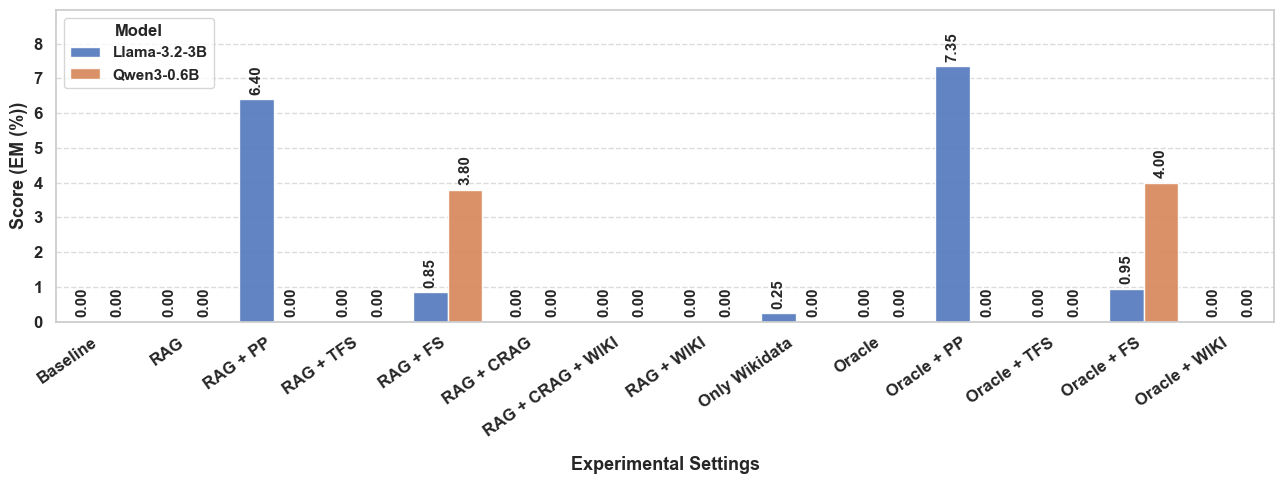

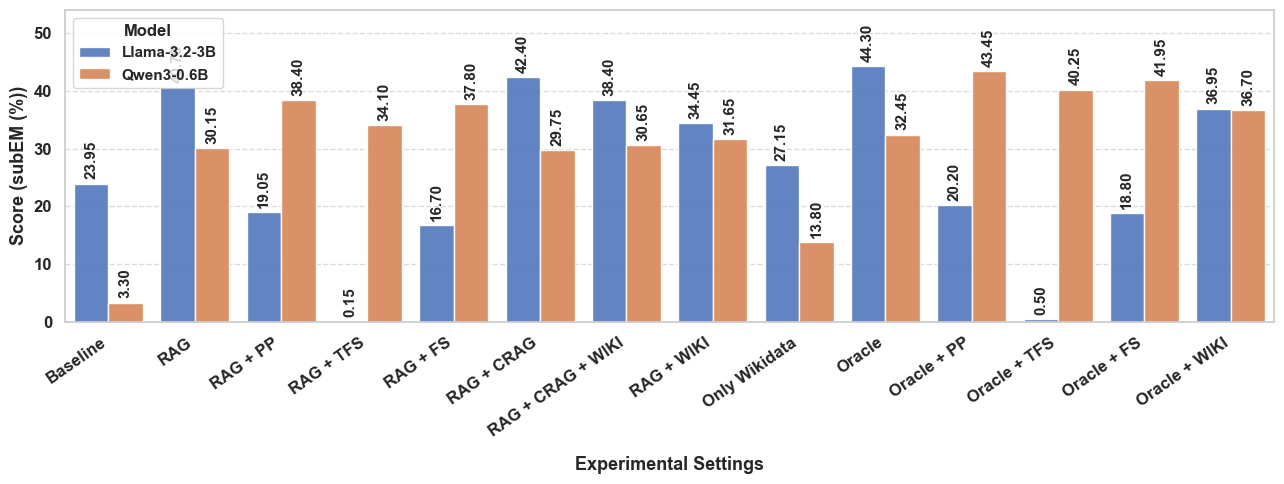

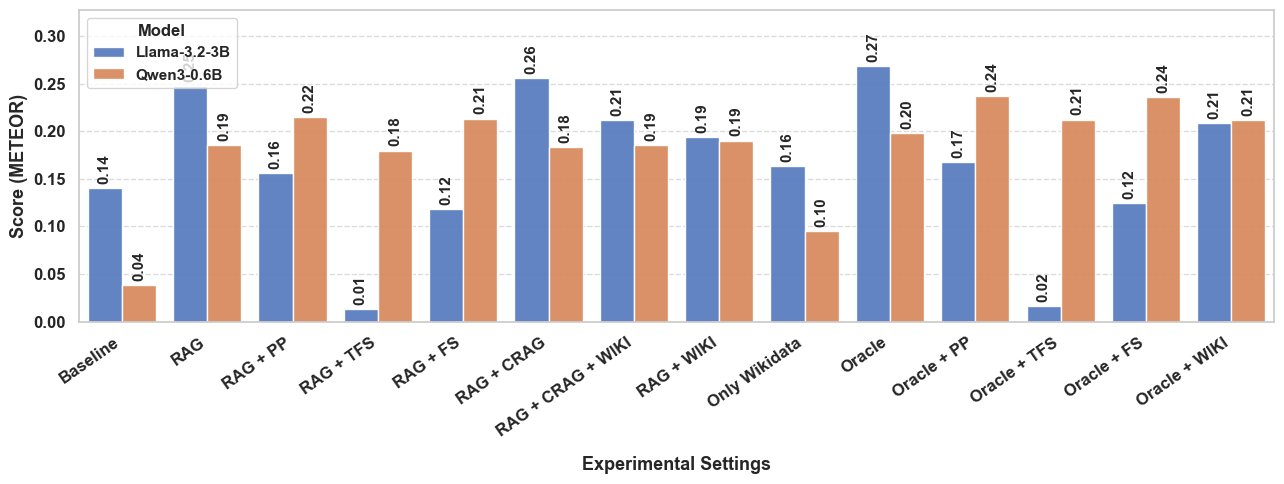

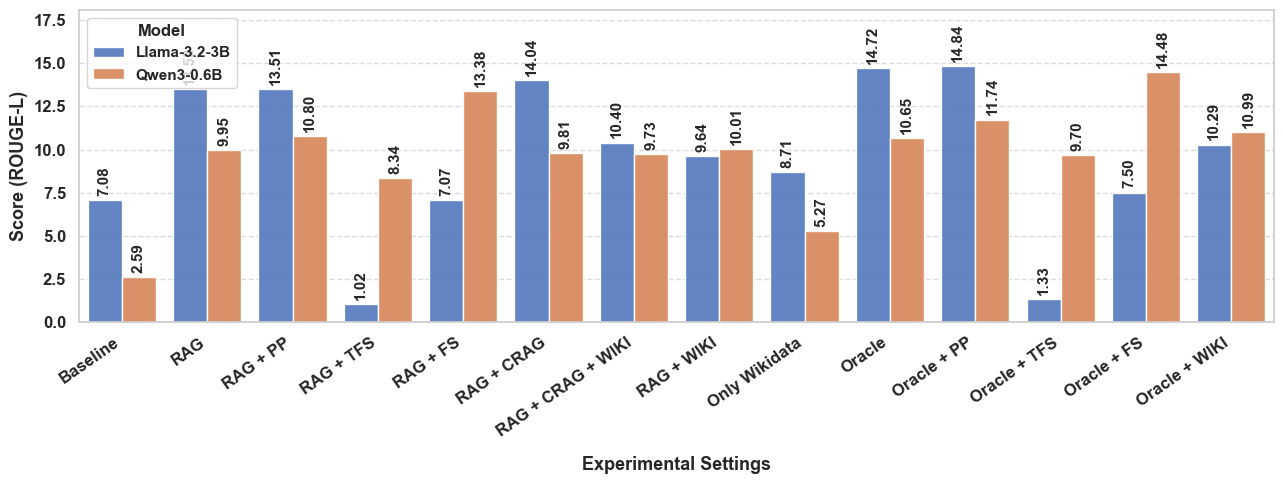

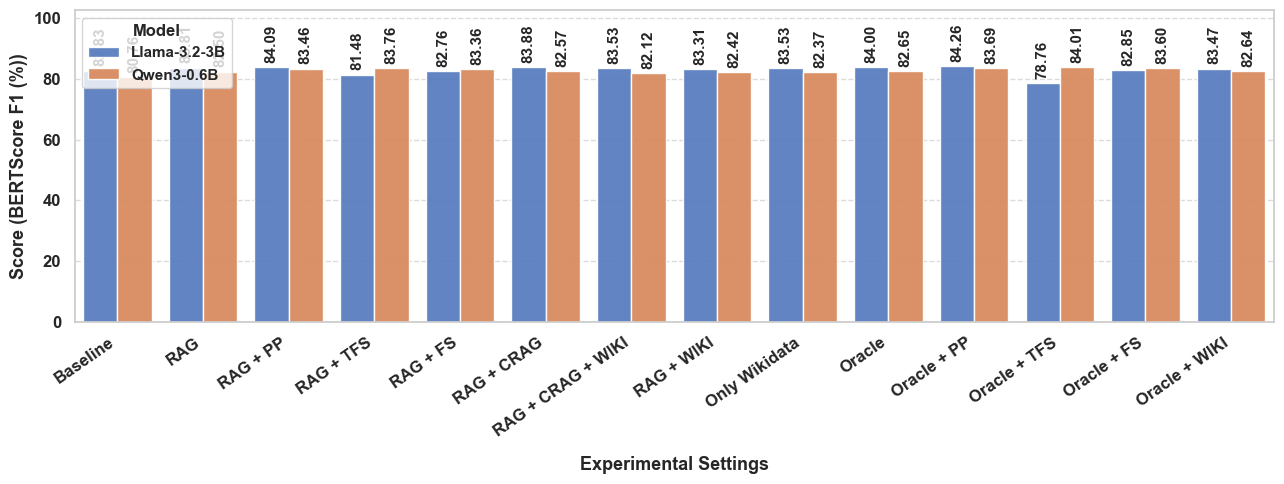

In [13]:
sns.set_theme(style="whitegrid")

metrics = ["EM (%)", "subEM (%)", "METEOR", "ROUGE-L", "BERTScore F1 (%)"]

setup_order = [
    "Baseline", "RAG", "RAG + PP", "RAG + TFS", "RAG + FS", 
    "RAG + CRAG", "RAG + CRAG + WIKI", "RAG + WIKI", 
    "Only Wikidata", "Oracle", "Oracle + PP", "Oracle + TFS", 
    "Oracle + FS", "Oracle + WIKI"
]

for metric in metrics:
    fig, ax = plt.subplots(figsize=(13, 5.0))

    sns.barplot(
        data=df_results,
        x="Setup",
        y=metric,
        hue="Model",
        order=setup_order,
        palette="muted",
        alpha=0.95,
        ax=ax
    )

    
    for container in ax.containers:
        ax.bar_label(container, fmt='%.2f', padding=3, fontsize=11, weight='bold', rotation=90)

    
    ax.set_xlabel("Experimental Settings", fontsize=13, weight='bold', labelpad=12)
    ax.set_ylabel(f"Score ({metric})", fontsize=13, weight='bold')

    ax.set_xticks(range(len(setup_order)))
    
    ax.set_xticklabels(setup_order, rotation=35, ha='right', fontsize=12, weight='bold')
    
    ax.tick_params(axis='y', labelsize=12)
    plt.setp(ax.get_yticklabels(), weight='bold')

    ax.xaxis.grid(False)
    ax.yaxis.grid(True, linestyle='--', alpha=0.7)

    max_value = df_results[metric].max()
    ax.set_ylim(0, max_value * 1.22 if max_value > 0 else 100.0)

    legend = ax.legend(title="Model", loc="upper left", frameon=True, fontsize=11, title_fontsize=12)
    
    plt.setp(legend.get_texts(), weight='bold')
    plt.setp(legend.get_title(), weight='bold')

    plt.tight_layout()

    file_name = f"plot_{metric.replace(' (%)', '').replace('-', '_').replace(' ', '_')}.pdf"
    save_path = os.path.join(PLOTS_DIR, file_name)
    plt.savefig(save_path, dpi=300, bbox_inches='tight')
    
    plt.show()

## **LLM as a Judge**

### **Model Initialization**

In [ ]:
test_limited = test.select(range(250))

llama_answers = dict(list(Llama_RAG_test_answers.items())[:250])
qwen_answers = dict(list(Qwen_RAG_test_answers.items())[:250])

api_key = input("Please enter your Google Generative AI API Key: ")
genai.configure(api_key=api_key)
gemini_31_flash = genai.GenerativeModel("models/gemini-3.1-flash-lite")

### **Judge Functions**

In [ ]:
def judge_correctness(query: str, generated_answer: str, short_answer: str, model) -> dict:

    prompt = f"""You are an impartial judge of my RAG system. Evaluate whether the answer is correct.

Query: {query}
Generated Answer: {generated_answer}
Short Answer: {short_answer}

1 → if the correct (short) answer is present in any valid form (e.g., “twenty-four”
instead of “24”, or “Rome was founded in 753 BCE” instead of “753 BCE”)
0 → if the correct (short) answer is not present in any valid form (e.g, “It was
located in Rome”, instead of the correct answer “Milan”)
Respond only with valid JSON: {{"score": <int>, "reasoning": "<string>"}}"""

    response = model.generate_content(
        prompt,
        generation_config=genai.GenerationConfig(response_mime_type="application/json")
    )

    return json.loads(response.text)

def llm_as_a_judge(predictions_dict, dataset, model):

    ground_truths = {item['query_id']: item['short_answer'] for item in dataset}
    queries = {item['query_id']: item['query'] for item in dataset}

    answers = {}
    results = []

    for i, (q_id, pred) in enumerate(predictions_dict.items()):

        s_answer = ground_truths.get(q_id, "")

        query = queries.get(q_id, "")
        gen_answer = pred.get("generated_answer", "")

        try:
            result = judge_correctness(query, gen_answer, s_answer, model)
            results.append({"query_id": q_id, **result})
            print(f"Judged sample {i+1}/{len(predictions_dict)}")
            # Rate limiting: max 15 RPM → wait 4 seconds between requests
            time.sleep(4)

        except Exception as e:
            print(f"Error sample {q_id}: {e}")
            time.sleep(60)  # backoff in case of errors
            result = {"score": 0, "reasoning": "API Error or Timeout"}

        answers[q_id] = {
            "query_id": q_id,
            "retrieved_chunks": pred.get("retrieved_chunks"),
            "augmented_prompt": pred.get("augmented_prompt"),
            "generated_answer": gen_answer,
            "short_answer": s_answer,
            "LLM Judge Score": result.get("score"),
            "LLM Judge Reasoning": result.get("reasoning")
        }

    print(f"Completed {len(results)} evaluations.")

    return answers

### **Judge Evaluation**

In [ ]:
gemini_llama_evaluations = llm_as_a_judge(llama_answers, test_limited, gemini_31_flash)
save_jsonl(gemini_llama_evaluations, "hit_k_1_-limited-test-Llama-3.2-3B-RAG-gemini3.1-flash-lite-evaluation.jsonl", NO_REQUESTED_OUTPUTS_DIR)
gemini_llama_evaluations = load_jsonl("hit_k_1_-limited-test-Llama-3.2-3B-RAG-gemini3.1-flash-lite-evaluation.jsonl", NO_REQUESTED_OUTPUTS_DIR)

list_llama = list(gemini_llama_evaluations.values())
df = pd.DataFrame(list_llama)
df.to_csv(os.path.join(NO_REQUESTED_OUTPUTS_DIR, "gemini_llama_evaluations.csv"), index=False, encoding='utf-8')


gemini_qwen_evaluations = llm_as_a_judge(qwen_answers, test_limited, gemini_31_flash)
save_jsonl(gemini_qwen_evaluations, "hit_k_1_-limited-test-Qwen3-0.6B-RAG-gemini3.1-flash-lite-evaluation.jsonl", NO_REQUESTED_OUTPUTS_DIR)
gemini_qwen_evaluations = load_jsonl("hit_k_1_-limited-test-Qwen3-0.6B-RAG-gemini3.1-flash-lite-evaluation.jsonl", NO_REQUESTED_OUTPUTS_DIR)

list_qwen = list(gemini_qwen_evaluations.values())
df = pd.DataFrame(list_qwen)
df.to_csv(os.path.join(NO_REQUESTED_OUTPUTS_DIR, "gemini_qwen_evaluations.csv"), index=False, encoding='utf-8')

✅ File loaded successfully: C:/Users/djmat/Desktop/Magistrale - Engineering in CS and AI - Sapienza/Multilingual_Natural_Language_Processing/MNLP_Project_2026\no_requested_outputs\hit_k_1_-limited-test-Llama-3.2-3B-RAG-gemini2.5-flash-evaluation.jsonl (250 query)


## **Manual Validation and LLM Judge Agreement**

### **Labels Loading**

In [15]:
df_llama = pd.read_csv(os.path.join(NO_REQUESTED_OUTPUTS_DIR if not kaggle else JSON_DIR, "gemini_llama_evaluations.csv"))
df_qwen = pd.read_csv(os.path.join(NO_REQUESTED_OUTPUTS_DIR if not kaggle else JSON_DIR, "gemini_qwen_evaluations.csv"))

# We save the DataFrames as JSON files as requested
llama_json_path = os.path.join(OUTPUTS_DIR if not kaggle else JSON_DIR, "gemini_llama_evaluations_with_manual_annotations.jsonl")
df_llama.to_json(llama_json_path, orient="records", lines=True, force_ascii=False)

qwen_json_path = os.path.join(OUTPUTS_DIR if not kaggle else JSON_DIR, "gemini_qwen_evaluations_with_manual_annotations.jsonl")
df_qwen.to_json(qwen_json_path, orient="records", lines=True, force_ascii=False)

In [16]:
# Accuracy Calculation

acc_mattia_llama = df_llama['Annotator 1 (Mattia)'].mean() * 100
acc_nicolo_llama = df_llama['Annotator 2 (Nicolo)'].mean() * 100
acc_gemini_llama = df_llama['LLM Judge Score'].mean() * 100

acc_mattia_qwen = df_qwen['Annotator 1 (Mattia)'].mean() * 100
acc_nicolo_qwen = df_qwen['Annotator 2 (Nicolo)'].mean() * 100
acc_gemini_qwen = df_qwen['LLM Judge Score'].mean() * 100

df_accuracy = pd.DataFrame({
    "Judge": [
        "Mattia",
        "Nicolò",
        "Gemini (LLM)"
    ],
    "Accuracy Llama (%)": [acc_mattia_llama, acc_nicolo_llama, acc_gemini_llama],
    "Accuracy Qwen (%)": [acc_mattia_qwen, acc_nicolo_qwen, acc_gemini_qwen]
}).round(1)

print("--- ACCURACY (Performance) ---")
display(df_accuracy)


# Kappa Coefficient Calculation t

kappa_mattia_nicolo_llama = cohen_kappa_score(df_llama['Annotator 1 (Mattia)'].to_numpy(), df_llama['Annotator 2 (Nicolo)'].to_numpy())
kappa_mattia_gemini_llama = cohen_kappa_score(df_llama['Annotator 1 (Mattia)'].to_numpy(), df_llama['LLM Judge Score'].to_numpy())
kappa_nicolo_gemini_llama = cohen_kappa_score(df_llama['Annotator 2 (Nicolo)'].to_numpy(), df_llama['LLM Judge Score'].to_numpy())

kappa_mattia_nicolo_qwen = cohen_kappa_score(df_qwen['Annotator 1 (Mattia)'].to_numpy(), df_qwen['Annotator 2 (Nicolo)'].to_numpy())
kappa_mattia_gemini_qwen = cohen_kappa_score(df_qwen['Annotator 1 (Mattia)'].to_numpy(), df_qwen['LLM Judge Score'].to_numpy())
kappa_nicolo_gemini_qwen = cohen_kappa_score(df_qwen['Annotator 2 (Nicolo)'].to_numpy(), df_qwen['LLM Judge Score'].to_numpy())

df_kappa = pd.DataFrame({
    "Judges couples": [
        "Mattia vs Nicolò (Umani)",
        "Mattia vs Gemini (Umano-LLM)",
        "Nicolò vs Gemini (Umano-LLM)"
    ],
    "Kappa Llama": [kappa_mattia_nicolo_llama, kappa_mattia_gemini_llama, kappa_nicolo_gemini_llama],
    "Kappa Qwen": [kappa_mattia_nicolo_qwen, kappa_mattia_gemini_qwen, kappa_nicolo_gemini_qwen]
}).round(3)

print("\n--- AGREEMENT (Cohen's Kappa) ---")
display(df_kappa)

--- ACCURACY (Performance) ---


,Judge,Accuracy Llama (%),Accuracy Qwen (%)
0,Mattia,60.4,44.0
1,Nicolò,57.2,44.4
2,Gemini (LLM),64.4,58.8



--- AGREEMENT (Cohen's Kappa) ---


,Judges couples,Kappa Llama,Kappa Qwen
0,Mattia vs Nicolò (Umani),0.852,0.911
1,Mattia vs Gemini (Umano-LLM),0.694,0.459
2,Nicolò vs Gemini (Umano-LLM),0.616,0.467


### **Plot Area**

Accuracy plot saved to: C:/Users/djmat/Desktop/Magistrale - Engineering in CS and AI - Sapienza/Multilingual_Natural_Language_Processing/MNLP_Project_2026\plots\plot_human_eval_accuracy.pdf


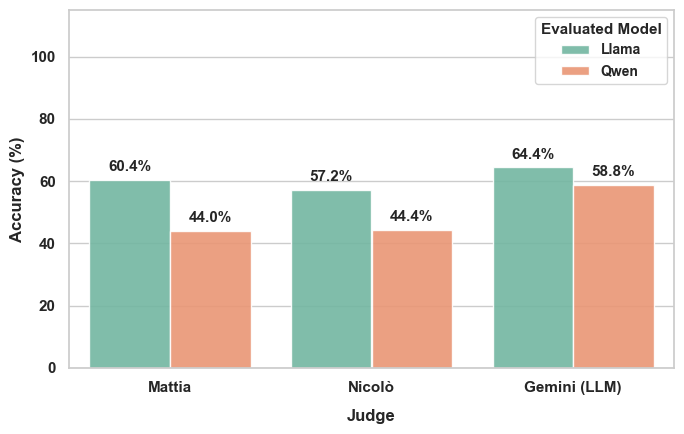

Kappa plot saved to: C:/Users/djmat/Desktop/Magistrale - Engineering in CS and AI - Sapienza/Multilingual_Natural_Language_Processing/MNLP_Project_2026\plots\plot_human_eval_kappa.pdf


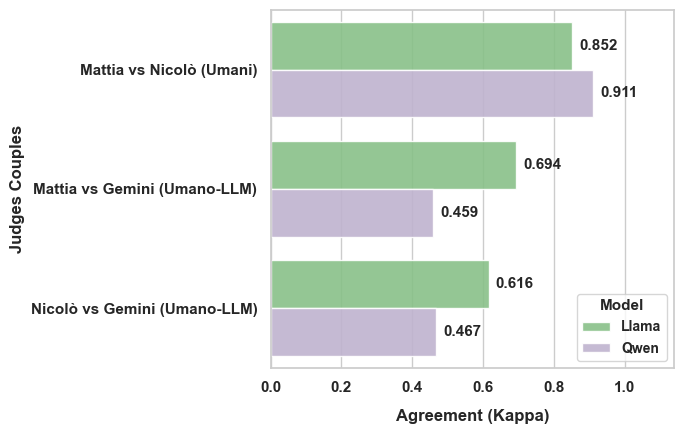

In [18]:

sns.set_theme(style="whitegrid")

df_acc_long = pd.melt(
    df_accuracy,
    id_vars=["Judge"],
    value_vars=["Accuracy Llama (%)", "Accuracy Qwen (%)"],
    var_name="Model",
    value_name="Accuracy"
)

df_acc_long["Model"] = df_acc_long["Model"].str.replace("Accuracy ", "").str.replace(" (%)", "")

fig, ax = plt.subplots(figsize=(7, 4.5))
sns.barplot(
    data=df_acc_long,
    x="Judge",
    y="Accuracy",
    hue="Model",
    palette="Set2",
    alpha=0.9,
    ax=ax
)

for container in ax.containers:
    ax.bar_label(container, fmt='%.1f%%', padding=4, fontsize=11, weight='bold')


ax.set_xlabel("Judge", fontsize=12, weight='bold', labelpad=10)
ax.set_ylabel("Accuracy (%)", fontsize=12, weight='bold')
ax.set_ylim(0, 115)


plt.setp(ax.get_xticklabels(), weight='bold', fontsize=11)
plt.setp(ax.get_yticklabels(), weight='bold', fontsize=11)


legend1 = ax.legend(title="Evaluated Model", loc="upper right", frameon=True, fontsize=10, title_fontsize=11)
plt.setp(legend1.get_texts(), weight='bold')
plt.setp(legend1.get_title(), weight='bold')

plt.tight_layout()

path_acc = os.path.join(PLOTS_DIR, "plot_human_eval_accuracy.pdf")
plt.savefig(path_acc, dpi=300, bbox_inches='tight')
print(f"Accuracy plot saved to: {path_acc}")
plt.show()


df_kappa_long = pd.melt(
    df_kappa,
    id_vars=["Judges couples"],
    value_vars=["Kappa Llama", "Kappa Qwen"],
    var_name="Model",
    value_name="Kappa"
)
df_kappa_long["Model"] = df_kappa_long["Model"].str.replace("Kappa ", "")


fig, ax = plt.subplots(figsize=(7, 4.5))
sns.barplot(
    data=df_kappa_long,
    y="Judges couples",
    x="Kappa",
    hue="Model",
    palette="Accent",
    alpha=0.9,
    ax=ax
)


for container in ax.containers:
    ax.bar_label(container, fmt='%.3f', padding=5, fontsize=11, weight='bold')

ax.set_xlabel("Agreement (Kappa)", fontsize=12, weight='bold', labelpad=10)
ax.set_ylabel("Judges Couples", fontsize=12, weight='bold')

plt.setp(ax.get_xticklabels(), weight='bold', fontsize=11)
plt.setp(ax.get_yticklabels(), weight='bold', fontsize=11)

max_kappa = df_kappa_long["Kappa"].max()
ax.set_xlim(0, max_kappa * 1.25 if max_kappa > 0 else 1.0)

legend2 = ax.legend(title="Model", loc="lower right", frameon=True, fontsize=10, title_fontsize=11)
plt.setp(legend2.get_texts(), weight='bold')
plt.setp(legend2.get_title(), weight='bold')

plt.tight_layout()

path_kappa = os.path.join(PLOTS_DIR, "plot_human_eval_kappa.pdf")
plt.savefig(path_kappa, dpi=300, bbox_inches='tight')
print(f"Kappa plot saved to: {path_kappa}")
plt.show()

## **Faithfulness Detection**

### **Faithfulness Functions**


In [15]:
def judge_faithfulness(generated_answer: str, retrieved_chunks: str, model) -> dict:

    prompt = f"""You are a strict Faithfulness Judge for a RAG (Retrieval-Augmented Generation) system.

Your ONLY job is to decide whether every claim in the Generated Answer can be directly inferred from the Retrieved Context.
You must IGNORE your own world knowledge: even a factually correct statement counts as UNFAITHFUL if it is not supported by the context.

---
RETRIEVED CONTEXT:
{retrieved_chunks}

---
GENERATED ANSWER:
{generated_answer}

---
SCORING SCALE:
5 → Every single claim in the answer is explicitly or clearly implicitly supported by the context.
4 → Nearly all claims are grounded; at most one minor unsupported detail present.
3 → Most claims are grounded, but there are noticeable gaps or mild extrapolations beyond the context.
2 → Several claims go beyond or contradict the context; hallucinated and grounded content are mixed significantly.
1 → The answer mostly or entirely ignores or contradicts the context (total hallucination).

---
INSTRUCTIONS — follow this exact chain-of-thought order before scoring:

Step 1 – List the key factual claims made in the Generated Answer (bullet points).
Step 2 – For each claim, state whether it is SUPPORTED, PARTIALLY SUPPORTED, or UNSUPPORTED by the Retrieved Context, and quote or cite the relevant part of the context (or note its absence).
Step 3 – Weigh the overall proportion of unsupported or contradicted claims.
Step 4 – Assign a score from 1 to 5 based on the scale above.

Output ONLY valid JSON with this exact structure (reasoning MUST come before score):
{{
  "reasoning": "<your full chain-of-thought from Steps 1-3>",
  "score": <integer 1-5>
}}"""

    response = model.generate_content(
        prompt,
        generation_config=genai.GenerationConfig(response_mime_type="application/json")
    )
    return json.loads(response.text)


def llm_judge_faithfulness(predictions_dict: dict, dataset, model):

    # Build a lookup: query_id → candidate_chunks
    chunks_lookup = dict(zip(dataset['query_id'], dataset['candidate_chunks']))

    answers = {}

    for i, (q_id, pred) in enumerate(predictions_dict.items(), start=1):

        gen_answer = pred.get("generated_answer", "")
        chunk_indices = pred.get("retrieved_chunks", [])

        # Resolve indices → actual text
        candidates = chunks_lookup.get(q_id, [])
        chunks_text = "\n\n".join(candidates[idx] for idx in chunk_indices)

        try:
            result = judge_faithfulness(gen_answer, chunks_text, model)
            print(f"Judged sample {i}/{len(predictions_dict)} — score: {result.get('score')}")
            time.sleep(4)
            
        except Exception as e:
            print(f"Error sample {q_id}: {e}")
            time.sleep(60)
            result = {"score": 0, "reasoning": "API Error or Timeout"}

        answers[q_id] = {
            "query_id": q_id,
            "retrieved_chunks": chunk_indices,
            "generated_answer": gen_answer,
            "Faithfulness Score": result.get("score"),
            "Faithfulness Reasoning": result.get("reasoning"),
        }

    return answers

### **Judge Evaluation**

In [ ]:
gemini_llama_faithfulness = llm_judge_faithfulness(llama_answers, test_limited, gemini_31_flash)
save_jsonl(gemini_llama_faithfulness, "llama_faithfulness.jsonl", OUTPUTS_DIR)
gemini_llama_faithfulness = load_jsonl("llama_faithfulness.jsonl", OUTPUTS_DIR)

df_llama_faith = pd.DataFrame(list(gemini_llama_faithfulness.values()))
df_llama_faith.to_csv(os.path.join(NO_REQUESTED_OUTPUTS_DIR, "llama_faithfulness.csv"), index=False, encoding='utf-8')


gemini_qwen_faithfulness = llm_judge_faithfulness(qwen_answers,  test_limited, gemini_31_flash)
save_jsonl(gemini_qwen_faithfulness, "qwen_faithfulness.jsonl",  OUTPUTS_DIR)
gemini_qwen_faithfulness = load_jsonl("qwen_faithfulness.jsonl",  OUTPUTS_DIR)

df_qwen_faith = pd.DataFrame(list(gemini_qwen_faithfulness.values()))
df_qwen_faith.to_csv(os.path.join(NO_REQUESTED_OUTPUTS_DIR, "qwen_faithfulness.csv"),  index=False, encoding='utf-8')

Judged sample 1/250 — score: 5
Judged sample 2/250 — score: 1
Judged sample 3/250 — score: 5
Judged sample 4/250 — score: 5
Judged sample 5/250 — score: 3
Judged sample 6/250 — score: 5
Judged sample 7/250 — score: 1
Judged sample 8/250 — score: 4
Judged sample 9/250 — score: 5
Judged sample 10/250 — score: 2
Judged sample 11/250 — score: 5
Judged sample 12/250 — score: 4
Judged sample 13/250 — score: 5
Judged sample 14/250 — score: 5
Judged sample 15/250 — score: 1
Judged sample 16/250 — score: 1
Judged sample 17/250 — score: 1
Judged sample 18/250 — score: 1
Judged sample 19/250 — score: 2
Judged sample 20/250 — score: 3
Judged sample 21/250 — score: 5
Judged sample 22/250 — score: 1
Judged sample 23/250 — score: 5
Judged sample 24/250 — score: 1
Judged sample 25/250 — score: 1
Judged sample 26/250 — score: 5
Judged sample 27/250 — score: 5
Judged sample 28/250 — score: 5
Judged sample 29/250 — score: 1
Judged sample 30/250 — score: 2
Judged sample 31/250 — score: 1
Judged sample 32/

### **Statistics**

In [19]:
df_llama_faith = pd.read_csv(os.path.join(NO_REQUESTED_OUTPUTS_DIR if not kaggle else JSON_DIR, "llama_faithfulness.csv"))
df_qwen_faith = pd.read_csv(os.path.join(NO_REQUESTED_OUTPUTS_DIR if not kaggle else JSON_DIR, "qwen_faithfulness.csv"))

In [20]:
df_faith_summary = pd.DataFrame({
    "Model": ["Llama-3.2-3B", "Qwen3-0.6B"],
    "Mean Faithfulness Score": [
        df_llama_faith["Faithfulness Score"].mean(),
        df_qwen_faith["Faithfulness Score"].mean()
    ],
    "Standard Deviation": [
        df_llama_faith["Faithfulness Score"].std(),
        df_qwen_faith["Faithfulness Score"].std()
    ],
    "% Score 5 (Perfectly Faithful)": [
        (df_llama_faith["Faithfulness Score"] == 5).mean() * 100,
        (df_qwen_faith["Faithfulness Score"]  == 5).mean() * 100
    ],
    "% Score 1 (Total Hallucination)": [
        (df_llama_faith["Faithfulness Score"] == 1).mean() * 100,
        (df_qwen_faith["Faithfulness Score"]  == 1).mean() * 100
    ],
}).round(2)

print("--- FAITHFULNESS SUMMARY ---")
display(df_faith_summary)

--- FAITHFULNESS SUMMARY ---


,Model,Mean Faithfulness Score,Standard Deviation,% Score 5 (Perfectly Faithful),% Score 1 (Total Hallucination)
0,Llama-3.2-3B,3.17,1.74,42.0,28.4
1,Qwen3-0.6B,2.75,1.78,34.0,41.6


### **Plot Area**

Mean faithfulness plot saved to: C:/Users/djmat/Desktop/Magistrale - Engineering in CS and AI - Sapienza/Multilingual_Natural_Language_Processing/MNLP_Project_2026\plots\plot_faithfulness_mean.pdf


C:\Users\djmat\AppData\Local\Temp\ipykernel_22436\4214386210.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


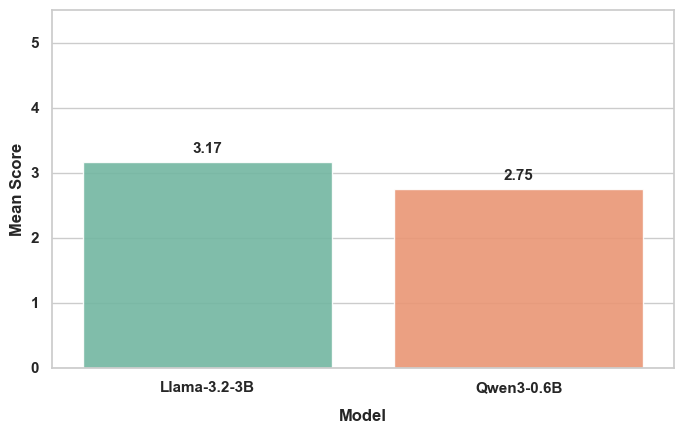

Distribution faithfulness plot saved to: C:/Users/djmat/Desktop/Magistrale - Engineering in CS and AI - Sapienza/Multilingual_Natural_Language_Processing/MNLP_Project_2026\plots\plot_faithfulness_distribution.pdf


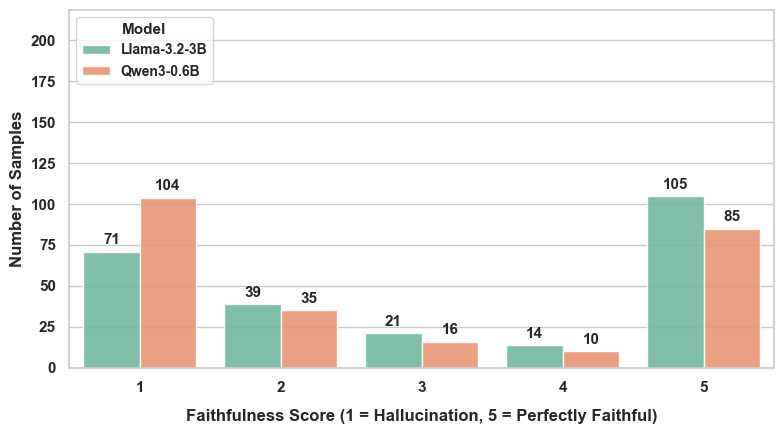

In [25]:
sns.set_theme(style="whitegrid")

fig, ax = plt.subplots(figsize=(7, 4.5))

sns.barplot(
    data=df_faith_summary,
    x="Model",
    y="Mean Faithfulness Score",
    palette="Set2",
    alpha=0.9,
    ax=ax
)


for container in ax.containers:
    ax.bar_label(container, fmt='%.2f', padding=4, fontsize=11, weight='bold')


ax.set_xlabel("Model", fontsize=12, weight='bold', labelpad=10)
ax.set_ylabel("Mean Score", fontsize=12, weight='bold')
ax.set_ylim(0, 5.5)


plt.setp(ax.get_xticklabels(), weight='bold', fontsize=11)
plt.setp(ax.get_yticklabels(), weight='bold', fontsize=11)

plt.tight_layout()
path_mean = os.path.join(PLOTS_DIR, "plot_faithfulness_mean.pdf")
plt.savefig(path_mean, dpi=300, bbox_inches='tight')
print(f"Mean faithfulness plot saved to: {path_mean}")
plt.show()

df_llama_faith["Model"] = "Llama-3.2-3B"
df_qwen_faith["Model"]  = "Qwen3-0.6B"
df_combined = pd.concat([df_llama_faith, df_qwen_faith], ignore_index=True)

fig, ax = plt.subplots(figsize=(8, 4.5))

sns.countplot(
    data=df_combined,
    x="Faithfulness Score",
    hue="Model",
    palette="Set2",
    alpha=0.9,
    ax=ax
)

for container in ax.containers:
    ax.bar_label(container, padding=3, fontsize=11, weight='bold')

ax.set_xlabel("Faithfulness Score (1 = Hallucination, 5 = Perfectly Faithful)", fontsize=12, weight='bold', labelpad=10)
ax.set_ylabel("Number of Samples", fontsize=12, weight='bold')


plt.setp(ax.get_xticklabels(), weight='bold', fontsize=11)
plt.setp(ax.get_yticklabels(), weight='bold', fontsize=11)


max_count = df_combined["Faithfulness Score"].value_counts().max()
ax.set_ylim(0, max_count * 1.15 if max_count > 0 else 100)

legend = ax.legend(title="Model", loc="upper left", frameon=True, fontsize=10, title_fontsize=11)
plt.setp(legend.get_texts(), weight='bold')
plt.setp(legend.get_title(), weight='bold')

plt.tight_layout()
path_dist = os.path.join(PLOTS_DIR, "plot_faithfulness_distribution.pdf")
plt.savefig(path_dist, dpi=300, bbox_inches='tight')
print(f"Distribution faithfulness plot saved to: {path_dist}")
plt.show()